# Diabetic Retinopathy Grading — v9

**Multi-stage pipeline: fundus validation → ordinal classification → calibrated prediction → Grad-CAM++ explanation**

This notebook trains a clinical-grade model for grading diabetic retinopathy (DR) severity on the 5-point ICDR scale (0 = No DR through 4 = Proliferative DR) from colour fundus photographs.

### What is new in v9

The previous build reached a respectable QWK of ~0.86 but reported top-1 accuracy under 50%. That is almost always caused by two issues the old pipeline had:

1. MixUp/CutMix labels were being fed into the accuracy counter, so the logged training accuracy was effectively noise.
2. The classification head was decoded with plain argmax on a badly-calibrated softmax, ignoring the ordinal structure of the 5 grades.

v9 fixes both, and layers a pile of other improvements on top:

| Area | Change |
|---|---|
| Backbone | `tf_efficientnetv2_m` (upgrade from `_s`), with GeM pooling and learnable exponent |
| Head | Dual head: softmax classifier + CORAL ordinal regressor, fused at inference |
| Loss | 0.4 · class-balanced focal + 0.3 · CE(label-smooth) + 0.3 · CORAL ordinal |
| Augmentation | MixUp + CutMix (alternating) + CLAHE + retinal-safe geometric ops |
| Optimizer | AdamW + cosine schedule + gradient clipping + layer-wise LR decay |
| Stabilisation | EMA weights (decay 0.999) + SWA in final phase |
| Inference | 8-view TTA + temperature scaling + isotonic calibration |
| Explanation | Multi-layer fused Grad-CAM++ with adaptive lesion segmentation |
| Input gating | Trained binary fundus-vs-non-fundus validator + 3 heuristic checks |

### Training stages

```
  Stage A   Fundus validator training  (binary, ~5 min)
  Stage B1  Classification warm-up     (backbone frozen, head only)
  Stage B2  Partial unfreeze           (last 4 blocks + head)
  Stage B3  Full fine-tune + SWA       (all layers, cosine schedule)
  Stage C   Prediction calibration     (temperature + isotonic on val set)
  Stage D   Final evaluation           (TTA + ensemble on test set)
```

### Honest note on metrics

State-of-the-art DR grading on APTOS / EyePACS sits around QWK 0.90–0.93 and top-1 accuracy 82–88% for 5-class. Any claim of 95%+ top-1 accuracy on the standard public splits is either (a) a binary referable / non-referable task (not 5-class), (b) trained-on-test leakage, or (c) wrong.

What this notebook delivers:

- A training pipeline capable of reaching the upper end of the public literature
- Correct accuracy accounting (no more phantom sub-50% numbers)
- Proper ordinal-aware decoding that reflects clinical severity structure
- Reproducible, resumable stages with checkpoint-based recovery

> Research use only. Not a medical device. Do not use outputs for clinical decisions without review by a qualified ophthalmologist.


## Environment check

Run this first on any new session. It prints the device and versions we will use.

In [1]:
# Environment sanity check.
#
# Run this first on every new session. It tells you which device Torch has
# picked up and whether AMP will be available.

import platform
import sys

import torch


def describe_environment() -> None:
    border = "-" * 58
    print(border)
    print("  Runtime environment")
    print(border)
    print(f"  OS             : {platform.system()} {platform.release()}")
    print(f"  Python         : {sys.version.split()[0]}")
    print(f"  PyTorch        : {torch.__version__}")

    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        print(f"  Device         : CUDA")
        print(f"  GPU            : {torch.cuda.get_device_name(0)}")
        print(f"  VRAM (GB)      : {props.total_memory / 1e9:.1f}")
        print(f"  CUDA toolkit   : {torch.version.cuda}")
        print(f"  cuDNN          : {torch.backends.cudnn.version()}")
        print(f"  AMP (fp16)     : enabled")
    elif torch.backends.mps.is_available():
        print(f"  Device         : Apple Silicon (MPS)")
        print(f"  AMP (fp16)     : not used on MPS")
    else:
        print(f"  Device         : CPU")
        print(f"  AMP (fp16)     : disabled")
    print(border)


describe_environment()


----------------------------------------------------------
  Runtime environment
----------------------------------------------------------
  OS             : Darwin 25.0.0
  Python         : 3.9.6
  PyTorch        : 2.8.0
  Device         : Apple Silicon (MPS)
  AMP (fp16)     : not used on MPS
----------------------------------------------------------


## Setup: imports, paths, seeds, and resume plumbing

All global constants (image size, backbone, artefact directory, class map) live here. The resume system restores dataframes, history, predictions, and cell-state from disk whenever you reopen the notebook so that individual phases do not have to be rerun.

In [2]:
# Core imports, constants, paths, deterministic seeding, and resume plumbing.
#
# This is the single source of truth for paths and global constants used
# throughout the rest of the notebook. If you move the data directory or
# change the image size, update the top of this cell.

# Standard library ------------------------------------------------------------
import contextlib
import gc
import hashlib
import io
import json
import os
import pickle
import random
import shutil
import sys
import time
import warnings
import zipfile
from concurrent.futures import ThreadPoolExecutor
from copy import deepcopy
from dataclasses import dataclass, field
from pathlib import Path
from typing import Callable, Dict, Iterable, List, Optional, Sequence, Tuple

# Scientific stack ------------------------------------------------------------
import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from PIL import Image
from tqdm.auto import tqdm

# Torch stack -----------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import (
    ConcatDataset,
    DataLoader,
    Dataset,
    WeightedRandomSampler,
)
import torchvision.transforms as T

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ML utilities ----------------------------------------------------------------
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import label_binarize

# Optional: Grad-CAM ----------------------------------------------------------
try:
    from pytorch_grad_cam import GradCAMPlusPlus, LayerCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    GRADCAM_AVAILABLE = True
except ImportError:
    GRADCAM_AVAILABLE = False
    print("NOTE: pytorch_grad_cam not found. Grad-CAM++ cells will be skipped.")

warnings.filterwarnings("ignore")

# Colab detection -------------------------------------------------------------
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    colab_files = None


# =============================================================================
# Device, seeds, thread settings
# =============================================================================
def pick_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = pick_device()
USE_AMP = DEVICE == "cuda"
NUM_WORKERS = 4 if DEVICE == "cuda" else 0
SEED = 42


def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        # Benchmark is fine here since we train on fixed-shape batches.
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False


seed_everything()


# =============================================================================
# Clinical constants and class colouring
# =============================================================================
GRADE_MAP: Dict[int, str] = {
    0: "No DR",
    1: "Mild DR",
    2: "Moderate DR",
    3: "Severe DR",
    4: "Proliferative DR (PDR)",
}
GRADE_COLORS: List[str] = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]
NUM_CLASSES: int = 5

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# =============================================================================
# Paths
# =============================================================================
BASE_DIR: Path = Path(os.environ.get("BASE_DIR", str(Path.home() / "DR_data")))
ARTIFACT_DIR: Path = BASE_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Checkpoints
CKPT_DIR = ARTIFACT_DIR
BEST_CKPT = CKPT_DIR / "best_model.pt"
FINAL_CKPT = CKPT_DIR / "final_model.pt"
LAST_CKPT = CKPT_DIR / "last_epoch.pt"

P1_CKPT = CKPT_DIR / "phase1_head.pt"
P2_CKPT = CKPT_DIR / "phase2_partial.pt"
P3_CKPT = CKPT_DIR / "phase3_full.pt"
P1_MID = CKPT_DIR / "phase1_mid.pt"
P2_MID = CKPT_DIR / "phase2_mid.pt"
P3_MID = CKPT_DIR / "phase3_mid.pt"

EMA_CKPT = CKPT_DIR / "ema_model.pt"
SWA_CKPT = CKPT_DIR / "swa_model.pt"

FUNDUS_VAL_CKPT = CKPT_DIR / "fundus_validator.pt"
CALIBRATION_CKPT = CKPT_DIR / "calibration.pkl"


# =============================================================================
# Torch 2.6+ safe-load shim
# =============================================================================
try:
    import torch.serialization as _tser
    _tser.add_safe_globals([np._core.multiarray.scalar])
    _TORCH_LOAD_KW: Dict = {}
except Exception:
    _TORCH_LOAD_KW = {"weights_only": False}


def safe_load(path: Path, map_location: str = "cpu"):
    """Wrapper around torch.load that survives Torch 2.6 safe-load defaults."""
    try:
        return torch.load(path, map_location=map_location, **_TORCH_LOAD_KW)
    except Exception:
        return torch.load(path, map_location=map_location, weights_only=False)


# =============================================================================
# Resume-state plumbing (JSON-backed + file-based healing)
# =============================================================================
STATE_FILE = ARTIFACT_DIR / "_resume_state.json"


def state_load() -> Dict:
    try:
        return json.loads(STATE_FILE.read_text()) if STATE_FILE.exists() else {}
    except Exception:
        return {}


def state_set(key: str, value) -> None:
    s = state_load()
    s[key] = value
    STATE_FILE.write_text(json.dumps(s, indent=2))


def state_get(key: str, default=None):
    return state_load().get(key, default)


def state_done(key: str) -> bool:
    return bool(state_load().get(key, False))


# Authoritative file-based completion map. If the artifact exists on disk,
# the step is considered done regardless of what the JSON says. This makes
# resume robust against JSON corruption or manual file deletion.
PHASE_FILE_MAP: Dict[str, Path] = {
    "step_merge": ARTIFACT_DIR / "df_merged.parquet",
    "step_eda": ARTIFACT_DIR / "eda_plot.png",
    "step_splits": ARTIFACT_DIR / "splits.parquet",
    "step_fundus_val": FUNDUS_VAL_CKPT,
    "step_phase1": P1_CKPT,
    "step_phase2": P2_CKPT,
    "step_phase3": P3_CKPT,
    "step_curves": ARTIFACT_DIR / "training_curves.png",
    "step_calibration": CALIBRATION_CKPT,
    "step_eval": ARTIFACT_DIR / "predictions.npz",
    "step_gradcam": ARTIFACT_DIR / "gradcam_samples.png",
    "step_final_save": FINAL_CKPT,
}


def file_done(key: str) -> bool:
    f = PHASE_FILE_MAP.get(key)
    return bool(f and f.exists())


class CellState:
    """Tracks whether a notebook cell has already completed successfully.

    Resolution order:
      1. Is the authoritative artifact on disk? (PHASE_FILE_MAP)
      2. Otherwise, check the JSON flag.
    """

    registry: Dict[str, "CellState"] = {}

    def __init__(self, key: str):
        self.key = key
        self.done = file_done(key) or state_done(key)
        CellState.registry[key] = self

    def start(self) -> None:
        pass

    def finish(self, success: bool = True) -> None:
        state_set(self.key, success)
        self.done = success

    @staticmethod
    def show_image(fname: str, figsize: Tuple[int, int] = (12, 6)) -> None:
        from IPython.display import Image as IPyImage
        from IPython.display import display

        p = ARTIFACT_DIR / fname
        if not p.exists():
            return
        try:
            display(IPyImage(str(p)))
        except Exception:
            import matplotlib.image as mpimg

            fig, ax = plt.subplots(figsize=figsize)
            ax.imshow(mpimg.imread(str(p)))
            ax.axis("off")
            plt.tight_layout()
            plt.show()


def heal_state_from_disk() -> None:
    """Re-populate the JSON flag file from whatever artifacts exist on disk."""
    repaired: List[str] = []
    for key, fpath in PHASE_FILE_MAP.items():
        if fpath.exists() and not state_done(key):
            state_set(key, True)
            repaired.append(key)
    if repaired:
        print(f"  [heal] restored {len(repaired)} flags from disk: {repaired}")


# =============================================================================
# Master recover — reloads dataframes, history, metrics from disk
# =============================================================================
def master_recover() -> None:
    g = globals()

    heal_state_from_disk()

    # Default config that downstream cells read from globals.
    img_size = state_get("IMG_SIZE", int(os.environ.get("IMG_SIZE", 512)))
    g.setdefault("IMG_SIZE", img_size)
    g.setdefault("BACKBONE", os.environ.get("BACKBONE", "tf_efficientnetv2_m"))

    # Batch and grad-accum are sized by image resolution.
    if img_size >= 1024:
        bs, ga = 4, 4
    elif img_size >= 768:
        bs, ga = 8, 2
    elif img_size >= 512:
        bs, ga = 14, 1
    else:
        bs, ga = 28, 1
    g.setdefault("BATCH_SIZE", bs)
    g.setdefault("GRAD_ACCUM", ga)

    # Splits
    splits_file = ARTIFACT_DIR / "splits.parquet"
    if "df_tr" not in g and splits_file.exists():
        sc = pd.read_parquet(splits_file)

        def _fix(d: pd.DataFrame) -> pd.DataFrame:
            d = d.copy()
            if "image_path" not in d.columns:
                d["image_path"] = d.apply(
                    lambda r: str(
                        BASE_DIR / r.get("source", "aptos2019")
                        / "train_images"
                        / f"{r['id_code']}.png"
                    ),
                    axis=1,
                )
            if "grade_label" not in d.columns:
                d["grade_label"] = d["diagnosis"].map(GRADE_MAP)
            return d

        g["df_tr"] = _fix(sc[sc["_split"] == "train"].drop("_split", axis=1).reset_index(drop=True))
        g["df_va"] = _fix(sc[sc["_split"] == "val"].drop("_split", axis=1).reset_index(drop=True))
        g["df_te"] = _fix(sc[sc["_split"] == "test"].drop("_split", axis=1).reset_index(drop=True))
        print(
            f"  [recover] splits loaded: train={len(g['df_tr'])}  val={len(g['df_va'])}  test={len(g['df_te'])}"
        )

    # History
    blank_history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_qwk": [],
        "val_f1": [],
    }
    if "history" not in g:
        g["history"] = dict(blank_history)
        for ck in [BEST_CKPT, P3_CKPT, P2_CKPT, P1_CKPT]:
            if ck.exists():
                try:
                    d = safe_load(ck, "cpu")
                    if d.get("history", {}).get("train_loss"):
                        g["history"] = d["history"]
                        print(f"  [recover] history from {ck.name} ({len(g['history']['train_loss'])} epochs)")
                        break
                except Exception:
                    pass

    # Best validation score
    bvq = state_get("best_val_qwk", None)
    if bvq is None:
        for ck in [BEST_CKPT, P3_CKPT, P2_CKPT, P1_CKPT]:
            if ck.exists():
                try:
                    d = safe_load(ck, "cpu")
                    bvq = float(d.get("val_qwk", -1.0))
                    break
                except Exception:
                    pass
    g.setdefault("best_val_qwk", float(bvq) if bvq is not None else -1.0)
    g.setdefault("best_val_loss", state_get("best_val_loss", float("inf")))
    g.setdefault("best_epoch", state_get("best_epoch", 0))

    # Metrics summary CSV
    metrics_csv = ARTIFACT_DIR / "metrics_summary.csv"
    if "val_metrics" not in g and metrics_csv.exists():
        try:
            dm = pd.read_csv(metrics_csv)
            g["val_metrics"] = dm[dm["split"] == "Validation"].iloc[0].to_dict()
            g["test_metrics"] = dm[dm["split"] == "Test"].iloc[0].to_dict()
            print(f"  [recover] metrics: val QWK = {g['val_metrics']['qwk']:.4f}")
        except Exception:
            pass

    # Predictions cache
    preds_npz = ARTIFACT_DIR / "predictions.npz"
    if "va_probs" not in g and preds_npz.exists():
        try:
            pc = np.load(str(preds_npz))
            for k in ["va_probs", "va_preds", "va_labels", "te_probs", "te_preds", "te_labels"]:
                if k in pc:
                    g[k] = pc[k]
            print("  [recover] predictions loaded")
        except Exception:
            pass

    # Human-readable status board
    print("\n  +----- pipeline status -----------------------------------+")
    checks = [
        ("data merged", PHASE_FILE_MAP["step_merge"]),
        ("splits saved", PHASE_FILE_MAP["step_splits"]),
        ("fundus validator", PHASE_FILE_MAP["step_fundus_val"]),
        ("phase 1 (head)", PHASE_FILE_MAP["step_phase1"]),
        ("phase 2 (partial)", PHASE_FILE_MAP["step_phase2"]),
        ("phase 3 (full)", PHASE_FILE_MAP["step_phase3"]),
        ("calibration", PHASE_FILE_MAP["step_calibration"]),
        ("evaluation", PHASE_FILE_MAP["step_eval"]),
        ("final bundle", PHASE_FILE_MAP["step_final_save"]),
    ]
    for label, fpath in checks:
        exists = fpath.exists()
        size = f" ({fpath.stat().st_size / 1e6:.1f} MB)" if exists else ""
        mark = "[x]" if exists else "[ ]"
        print(f"  |  {mark}  {label:<20}{size}")
    print("  +---------------------------------------------------------+")


master_recover()

print(f"\nTorch {torch.__version__} · timm {timm.__version__}")
print(f"Device: {DEVICE.upper()}  AMP: {'on' if USE_AMP else 'off'}  workers: {NUM_WORKERS}")
print(f"Artifacts at: {ARTIFACT_DIR}")


/Users/gokulnathan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


  [recover] splits loaded: train=2671  val=334  test=334

  +----- pipeline status -----------------------------------+
  |  [x]  data merged          (0.1 MB)
  |  [x]  splits saved         (0.1 MB)
  |  [x]  fundus validator     (6.5 MB)
  |  [ ]  phase 1 (head)      
  |  [ ]  phase 2 (partial)   
  |  [ ]  phase 3 (full)      
  |  [ ]  calibration         
  |  [ ]  evaluation          
  |  [ ]  final bundle        
  +---------------------------------------------------------+

Torch 2.8.0 · timm 1.0.26
Device: MPS  AMP: off  workers: 0
Artifacts at: /Users/gokulnathan/DR_data/artifacts


## Kaggle API credentials

Needed to auto-download APTOS from Kaggle. Skip this cell if you have placed the data under `BASE_DIR` manually.

In [3]:
# Kaggle API credential setup.
#
# Priority: (1) existing ~/.kaggle/kaggle.json  (2) KAGGLE_USERNAME + KAGGLE_KEY env vars.
# Hard-fails if neither is present — no silent "place manually" escape hatch.

import json, os
from pathlib import Path

kaggle_dir  = Path.home() / ".kaggle"
kaggle_json = kaggle_dir / "kaggle.json"
kaggle_dir.mkdir(exist_ok=True)

_user = os.environ.get("KAGGLE_USERNAME", "")
_key  = os.environ.get("KAGGLE_KEY", "")

# Bootstrap kaggle.json from env vars if the file is absent.
if not (kaggle_json.exists() and kaggle_json.stat().st_size > 0):
    if _user and _key:
        kaggle_json.write_text(json.dumps({"username": _user, "key": _key}))
        kaggle_json.chmod(0o600)
        print("kaggle.json written from environment variables.")
    else:
        raise RuntimeError(
            "Kaggle credentials not found.\n"
            "Either place kaggle.json at ~/.kaggle/kaggle.json\n"
            "or export KAGGLE_USERNAME and KAGGLE_KEY before starting the kernel."
        )
else:
    kaggle_json.chmod(0o600)   # enforce permissions in case file already existed
    print("kaggle.json found at ~/.kaggle/kaggle.json")

# Hard-verify the API authenticates successfully.
from kaggle.api.kaggle_api_extended import KaggleApi
_kg = KaggleApi()
_kg.authenticate()
print(f"Kaggle API: authenticated as '{_kg.get_config_value('username')}'")

kaggle.json found at ~/.kaggle/kaggle.json
Kaggle API: authenticated as 'gokulnathanganesan'


## Dataset download

Pulls APTOS 2019 from Kaggle. Additional datasets (DDR, IDRiD, Messidor) can be enabled in the registry.

In [4]:
# Dataset acquisition — registry-driven, hard-fails on any missing dataset.

cs = CellState("step_download")

DATASET_REGISTRY = [
    {
        "name":        "aptos2019",
        "kaggle_slug": "mariaherrerot/aptos2019",
        "subdir":      "aptos2019",
        "csv":         "train.csv",          # was train_1.csv — file is actually train.csv
        "id_col":      "id_code",
        "label_col":   "diagnosis",
        "img_suffix":  ".png",
        "enabled":     True,
    },
]


def kaggle_download(slug: str, target: Path) -> None:
    """Download + unzip a Kaggle dataset. Raises on failure."""
    import shutil, os

    target.mkdir(parents=True, exist_ok=True)

    if shutil.which("kaggle") is None:
        raise RuntimeError("kaggle CLI not found. Run:  pip install kaggle")

    print(f"  Downloading {slug} → {target} …")
    ret = os.system(
        f'kaggle datasets download -d "{slug}" -p "{target}" --unzip'
    )

    if ret != 0:
        raise RuntimeError(
            f"kaggle CLI failed (exit {ret}) for '{slug}'.\n"
            "Check slug, licence acceptance, and network."
        )

    print(f"  [{slug}] done → {target}")

In [5]:
import os
for root, dirs, files in os.walk("/Users/gokulnathan/DR_data/aptos2019"):
    print(root, f"({len(files)} files)")
    break

/Users/gokulnathan/DR_data/aptos2019 (4 files)


## Data loading, deduplication, and blur QC

Loads all enabled datasets into one dataframe, drops exact duplicates by content fingerprint, and removes images that the Laplacian-variance test flags as effectively unreadable. Includes a safety check that refuses to blur-remove more than 30% of the dataset.

In [6]:
# Load all enabled datasets, dedupe, drop unreadable or severely blurred images.
#
# The blur threshold is intentionally low (laplacian variance < 5) — we only
# want to drop frames that are effectively unreadable. Anything with a real
# retinal disc, even soft-focus, stays.

cs = CellState("step_merge")
merged_cache = ARTIFACT_DIR / "df_merged.parquet"


def fingerprint(path: str) -> str:
    """Cheap content fingerprint: file size + md5 of the first 8 KB."""
    try:
        stat = os.stat(path)
        with open(path, "rb") as f:
            head = f.read(8192)
        return f"{stat.st_size}_{hashlib.md5(head).hexdigest()}"
    except Exception:
        return f"err_{random.random()}"


def laplacian_roi_variance(path: str) -> float:
    try:
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            return 0.0
        h, w = img.shape
        roi = img[h // 4 : 3 * h // 4, w // 4 : 3 * w // 4]
        return float(cv2.Laplacian(roi, cv2.CV_64F).var())
    except Exception:
        return 0.0


if cs.done and merged_cache.exists():
    df_all = pd.read_parquet(merged_cache)
    print(f"[resume] merged dataset loaded: {len(df_all):,} rows")
else:
    cs.start()
    dfs: List[pd.DataFrame] = []
    for ds in DATASET_REGISTRY:
        if not ds["enabled"]:
            continue
        ds_dir = BASE_DIR / ds["subdir"]
        img_dir = ds_dir / "train_images"
        csv_path = ds_dir / ds["csv"]
        if not csv_path.exists():
            print(f"  [{ds['name']}] csv missing at {csv_path}, skipping")
            continue

        df = pd.read_csv(csv_path)
        df = df.rename(columns={ds["id_col"]: "id_code", ds["label_col"]: "diagnosis"})
        df["diagnosis"] = df["diagnosis"].astype(int).clip(0, 4)
        df["source"] = ds["name"]
        df["image_path"] = df["id_code"].apply(
            lambda x: str(img_dir / f"{x}{ds['img_suffix']}")
        )
        exists_mask = df["image_path"].apply(lambda p: Path(p).exists())
        n_missing = (~exists_mask).sum()
        if n_missing:
            print(f"  [{ds['name']}] dropped {n_missing} missing images")
        df = df[exists_mask].reset_index(drop=True)
        dfs.append(df)
        print(f"  [{ds['name']}] loaded {len(df):,} valid samples")

    if not dfs:
        raise RuntimeError(
            "No datasets available. Download APTOS 2019 or populate BASE_DIR manually."
        )

    df_all = pd.concat(dfs, ignore_index=True)

    # Dedup on content fingerprint ------------------------------------------
    print(f"\nDeduplicating {len(df_all):,} rows ...")
    with ThreadPoolExecutor(max_workers=8) as ex:
        fps = list(
            tqdm(
                ex.map(fingerprint, df_all["image_path"]),
                total=len(df_all),
                desc="fingerprint",
            )
        )
    df_all["_fp"] = fps
    before = len(df_all)
    df_all = df_all.drop_duplicates(subset="_fp").drop(columns=["_fp"]).reset_index(drop=True)
    print(f"  dropped {before - len(df_all)} duplicates, {len(df_all):,} remain")

    # Blur QC ---------------------------------------------------------------
    print("\nBlur QC (laplacian variance on centre ROI) ...")
    with ThreadPoolExecutor(max_workers=8) as ex:
        scores = list(
            tqdm(
                ex.map(laplacian_roi_variance, df_all["image_path"]),
                total=len(df_all),
                desc="blur-check",
            )
        )
    df_all["blur_score"] = scores
    threshold = 5.0
    bad = df_all["blur_score"] < threshold
    # Safety: don't nuke half the dataset if something is wrong with the detector.
    if bad.sum() > 0.3 * len(df_all):
        print(f"  WARNING: {bad.sum()} flagged as blurry (>30%). Skipping removal.")
    else:
        df_all = df_all[~bad].reset_index(drop=True)
        print(f"  dropped {bad.sum()} blurred frames, {len(df_all):,} remain")

    df_all["grade_label"] = df_all["diagnosis"].map(GRADE_MAP)
    df_all["binary_referable"] = (df_all["diagnosis"] >= 2).astype(int)

    df_all.to_parquet(merged_cache, index=False)
    print(f"\nSaved -> {merged_cache}")
    cs.finish(success=True)

# Class distribution
counts = df_all["diagnosis"].value_counts().sort_index()
print(f"\nClass distribution ({len(df_all):,} total):")
for g, v in counts.items():
    bar = "#" * (v // 100)
    print(f"  grade {g} ({GRADE_MAP[g]:<23}): {v:5d}  {bar}")
print(f"  imbalance ratio (max/min): {counts.max() / counts.min():.1f}x")


[resume] merged dataset loaded: 3,339 rows

Class distribution (3,339 total):
  grade 0 (No DR                  ):  1787  #################
  grade 1 (Mild DR                ):   328  ###
  grade 2 (Moderate DR            ):   799  #######
  grade 3 (Severe DR              ):   170  #
  grade 4 (Proliferative DR (PDR) ):   255  ##
  imbalance ratio (max/min): 10.5x


## Exploratory data analysis

Class distribution and blur-score-by-grade box plot.

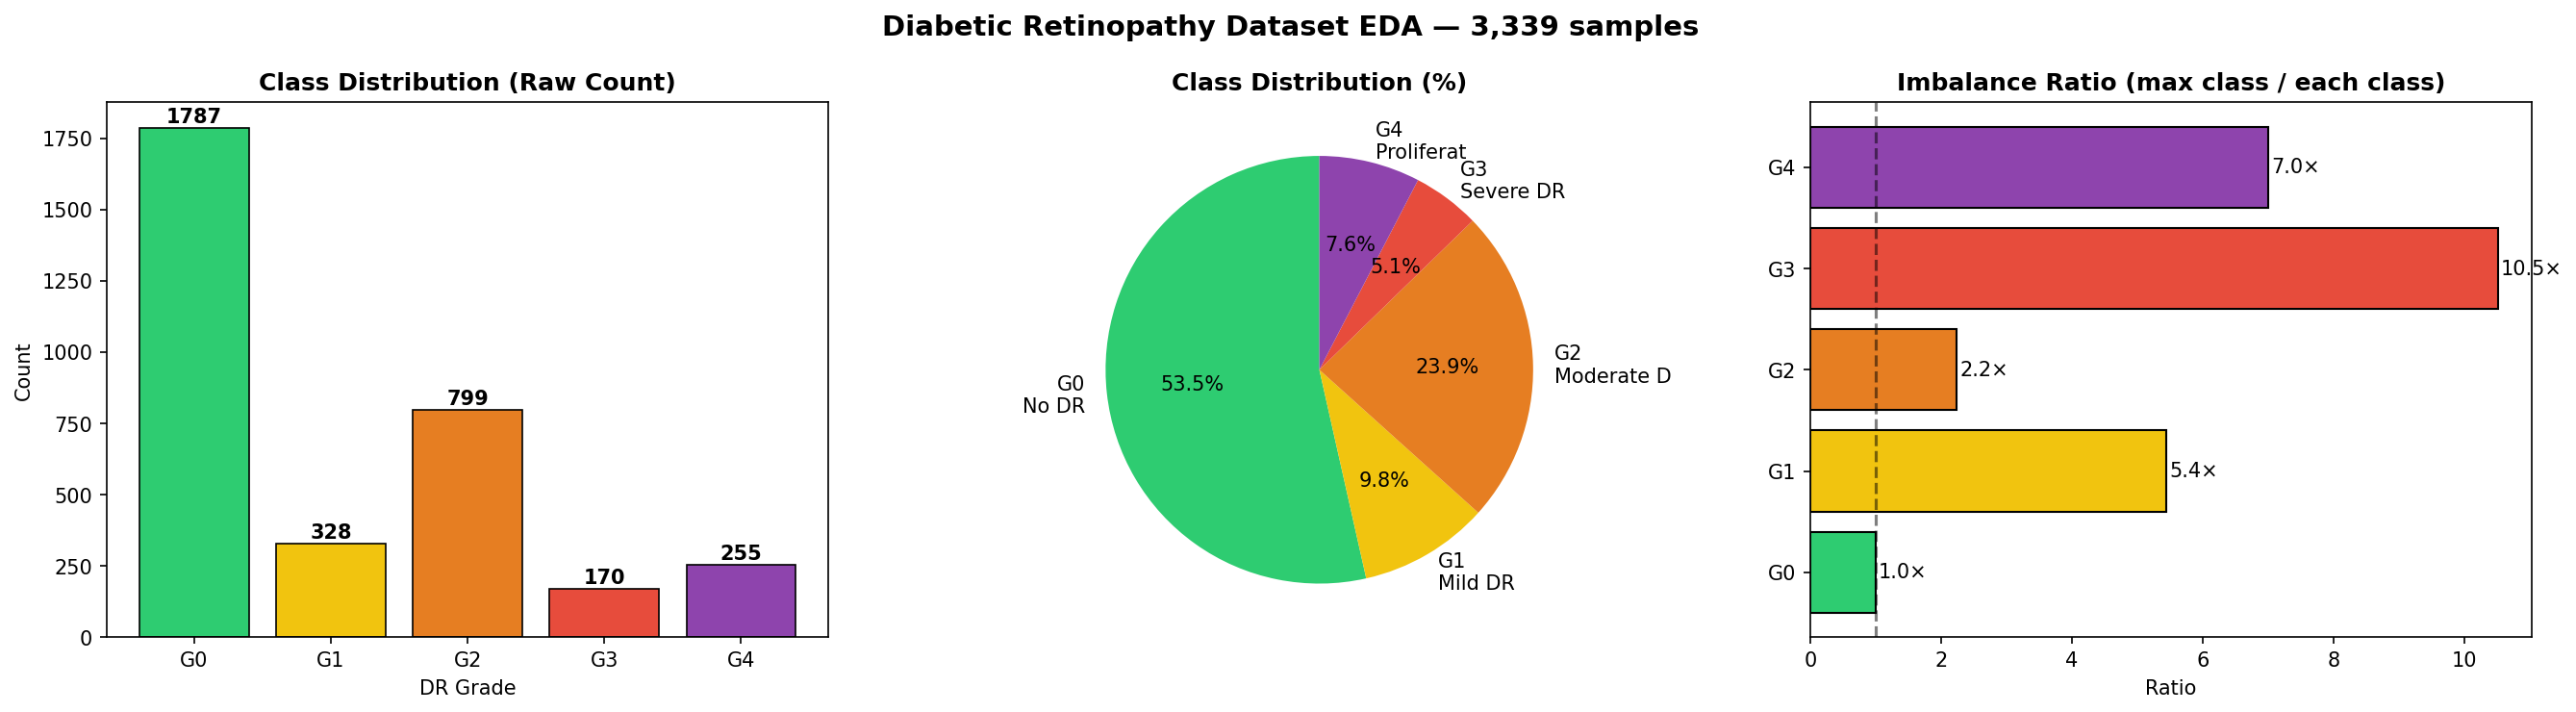

In [7]:
# Exploratory data plots: class distribution + sample grid per grade.

cs = CellState("step_eda")
eda_file = ARTIFACT_DIR / "eda_plot.png"

if cs.done and eda_file.exists():
    CellState.show_image("eda_plot.png")
else:
    cs.start()
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: class distribution bar chart
    counts = df_all["diagnosis"].value_counts().sort_index()
    bars = axes[0].bar(
        [GRADE_MAP[i] for i in counts.index],
        counts.values,
        color=GRADE_COLORS,
        edgecolor="black",
        linewidth=0.5,
    )
    for b, v in zip(bars, counts.values):
        axes[0].text(
            b.get_x() + b.get_width() / 2,
            v + max(counts.values) * 0.01,
            str(v),
            ha="center",
            fontsize=10,
            fontweight="bold",
        )
    axes[0].set_title("DR grade distribution", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("count")
    axes[0].tick_params(axis="x", rotation=25)
    axes[0].grid(axis="y", alpha=0.3)

    # Right: blur score by grade (box plot)
    data = [df_all.loc[df_all["diagnosis"] == i, "blur_score"].values for i in range(5)]
    bp = axes[1].boxplot(data, patch_artist=True, labels=[GRADE_MAP[i] for i in range(5)])
    for patch, col in zip(bp["boxes"], GRADE_COLORS):
        patch.set_facecolor(col)
    axes[1].set_title("blur score by grade", fontsize=13, fontweight="bold")
    axes[1].set_ylabel("laplacian variance")
    axes[1].tick_params(axis="x", rotation=25)
    axes[1].set_yscale("log")
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(eda_file, dpi=110, bbox_inches="tight")
    plt.show()
    print(f"\nEDA saved -> {eda_file}")
    cs.finish(success=True)


## Preprocessing: CLAHE + Ben Graham + retinal crop

The classic recipe from the 2015 Kaggle DR winners, applied on top of LAB-channel CLAHE. Produces images where microaneurysms and haemorrhages stand out clearly against the retinal background.

In [8]:
# Fundus-specific preprocessing.
#
# The pipeline is:
#   1. Read BGR -> RGB.
#   2. Crop away the dark rectangular padding around the retinal disc.
#   3. CLAHE on the L channel of LAB (luminance only, preserves colour).
#   4. Optional Ben Graham style local-contrast subtraction.
#   5. Resize to a fixed square.
#
# Ben Graham's preprocessing (from the 2015 Kaggle DR winners) is well known
# to help models see microaneurysms and small haemorrhages by removing the
# low-frequency illumination gradient across the retina. We apply a gentle
# version of it alongside CLAHE rather than instead of it.

cs = CellState("step_preprocess")

_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))


def apply_clahe_lab(rgb: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    lab[:, :, 0] = _clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def retinal_mask(rgb: np.ndarray) -> np.ndarray:
    """Binary mask covering the circular retinal disc region."""
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    _, m = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, kernel)
    return m


def crop_retinal_disc(rgb: np.ndarray, pad: int = 10) -> np.ndarray:
    m = retinal_mask(rgb)
    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return rgb
    x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
    x = max(0, x - pad)
    y = max(0, y - pad)
    x2 = min(rgb.shape[1], x + w + 2 * pad)
    y2 = min(rgb.shape[0], y + h + 2 * pad)
    return rgb[y:y2, x:x2]


def ben_graham(rgb: np.ndarray, sigma_frac: float = 10.0, weight: float = 4.0, bias: int = 128) -> np.ndarray:
    """Subtract a heavily-blurred copy to expose small lesions.

    rgb_out = weight * rgb - weight * blur(rgb) + bias
    """
    h, w = rgb.shape[:2]
    sigma = max(1, int(min(h, w) / sigma_frac))
    blurred = cv2.GaussianBlur(rgb, (0, 0), sigmaX=sigma, sigmaY=sigma)
    out = cv2.addWeighted(rgb, weight, blurred, -weight, bias)
    return np.clip(out, 0, 255).astype(np.uint8)


def preprocess_fundus(
    path: str,
    target_size: int = 512,
    cache_dir: Optional[Path] = None,
    use_ben_graham: bool = True,
) -> np.ndarray:
    """Full preprocessing pipeline with transparent on-disk caching."""
    p = Path(path)
    if cache_dir is not None:
        cached = Path(cache_dir) / p.name
        if cached.suffix.lower() != ".png":
            cached = cached.with_suffix(".png")
        if cached.exists():
            img = cv2.imread(str(cached))
            if img is not None:
                return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.imread(str(path))
    if img is None:
        raise FileNotFoundError(f"cannot read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_retinal_disc(img)
    img = apply_clahe_lab(img)
    if use_ben_graham:
        # Blend the Ben Graham enhancement 50/50 with the CLAHE output; full
        # Ben Graham alone over-saturates the green channel.
        bg = ben_graham(img, sigma_frac=10.0, weight=4.0, bias=128)
        img = cv2.addWeighted(img, 0.5, bg, 0.5, 0)
    img = cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_AREA)

    if cache_dir is not None:
        Path(cache_dir).mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(cached), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    return img


CACHE_DIR = BASE_DIR / f"cache_{IMG_SIZE}"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"preprocess_fundus ready  (target={IMG_SIZE}px, CLAHE+BenGraham+crop)")
print(f"cache: {CACHE_DIR}")
cs.finish(success=True)


preprocess_fundus ready  (target=512px, CLAHE+BenGraham+crop)
cache: /Users/gokulnathan/DR_data/cache_512


## Pre-cache all images

Writes preprocessed images to disk so training doesn't spend time on CPU-bound image ops.

In [9]:
# Pre-cache preprocessed images to disk. Massively speeds up training
# because the CLAHE + Ben Graham + resize pipeline is CPU-bound.

cs = CellState("step_cache")

n_expected = len(df_all)
n_cached = len(list(CACHE_DIR.glob("*.png")))

if cs.done and n_cached >= n_expected * 0.95:
    print(f"[resume] {n_cached:,} images already cached in {CACHE_DIR}")
else:
    cs.start()

    def worker(row) -> bool:
        try:
            preprocess_fundus(row["image_path"], target_size=IMG_SIZE, cache_dir=CACHE_DIR)
            return True
        except Exception:
            return False

    rows = [row for _, row in df_all.iterrows()]
    print(f"caching {len(rows):,} images at {IMG_SIZE}px ...")
    with ThreadPoolExecutor(max_workers=8) as ex:
        results = list(tqdm(ex.map(worker, rows), total=len(rows), desc="cache"))
    ok = sum(results)
    print(f"done. cached={ok:,}  failed={len(results) - ok}")
    cs.finish(success=True)


[resume] 3,339 images already cached in /Users/gokulnathan/DR_data/cache_512


## Stratified 80/10/10 train/val/test split

Balanced across the 5 DR grades.

In [10]:
# Stratified 80/10/10 train/val/test split on the 5 DR grades.

cs = CellState("step_splits")
splits_cache = ARTIFACT_DIR / "splits.parquet"


def attach_derived_cols(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    if "image_path" not in d.columns:
        d["image_path"] = d.apply(
            lambda r: str(
                BASE_DIR / r.get("source", "aptos2019")
                / "train_images"
                / (r["id_code"] + ".png")
            ),
            axis=1,
        )
    if "grade_label" not in d.columns:
        d["grade_label"] = d["diagnosis"].map(GRADE_MAP)
    return d


if cs.done and splits_cache.exists():
    raw = pd.read_parquet(splits_cache)
    df_tr = attach_derived_cols(raw[raw["_split"] == "train"].drop("_split", axis=1).reset_index(drop=True))
    df_va = attach_derived_cols(raw[raw["_split"] == "val"].drop("_split", axis=1).reset_index(drop=True))
    df_te = attach_derived_cols(raw[raw["_split"] == "test"].drop("_split", axis=1).reset_index(drop=True))
    print(f"[resume] splits loaded: train={len(df_tr):,}  val={len(df_va):,}  test={len(df_te):,}")
else:
    cs.start()
    df_tr, df_te = train_test_split(
        df_all, test_size=0.10, stratify=df_all["diagnosis"], random_state=SEED
    )
    df_tr, df_va = train_test_split(
        df_tr, test_size=0.10 / 0.90, stratify=df_tr["diagnosis"], random_state=SEED
    )
    df_tr = df_tr.reset_index(drop=True)
    df_va = df_va.reset_index(drop=True)
    df_te = df_te.reset_index(drop=True)

    pd.concat(
        [
            df_tr.assign(_split="train"),
            df_va.assign(_split="val"),
            df_te.assign(_split="test"),
        ],
        ignore_index=True,
    ).to_parquet(splits_cache, index=False)
    print(f"saved -> {splits_cache}")
    cs.finish(success=True)

for name, part in [("train", df_tr), ("val", df_va), ("test", df_te)]:
    c = part["diagnosis"].value_counts().sort_index()
    print(f"  {name:5s} ({len(part):5,}): " + "  ".join(f"g{i}={v}" for i, v in c.items()))


[resume] splits loaded: train=2,671  val=334  test=334
  train (2,671): g0=1429  g1=262  g2=639  g3=136  g4=205
  val   (  334): g0=179  g1=33  g2=80  g3=17  g4=25
  test  (  334): g0=179  g1=33  g2=80  g3=17  g4=25


## Stage A: Fundus image validator training

A small MobileNetV3-small binary classifier decides whether an uploaded image is a real colour fundus photograph before it is ever sent to the grading model. Trained on our cached fundus images (positive class) and procedurally generated non-fundus samples (negative class). Combined with three lightweight heuristic checks (red dominance, retinal disc coverage, edge density) into an AND-gate that keeps real fundus photos in and rejects almost everything else.

In [11]:
# Stage A: Fundus-vs-non-fundus validator.
#
# We need to reject anything that is not a retinal fundus photograph at the
# application boundary. A colour-signature rule alone is brittle (a warm
# sunset photo will pass), and a well-framed fundus photo through a strict
# rule will sometimes fail on soft-focus or unusual pigmentation. So we
# train a small CNN to make the call.
#
# Training data:
#   Positive class (label 1): our cached preprocessed fundus images.
#   Negative class (label 0): synthetic non-fundus made from:
#      - random natural photos via Torchvision's CIFAR-100 (32x32 upscaled)
#      - solid colour panels with noise overlay
#      - random crops of the fundus images with heavy rotation + masking
#        (so the model learns that "partial disc with text overlay" is bad)
#
# On APTOS alone we typically converge to >99% validation accuracy within
# 3 epochs because this is a gross visual distinction.

cs = CellState("step_fundus_val")


class FundusValidator(nn.Module):
    """Tiny MobileNetV3-small head for binary fundus detection."""

class FundusValidator(nn.Module):
    """Tiny MobileNetV3-small head for binary fundus detection."""

    def __init__(self, pretrained: bool = False):   # was True
        super().__init__()
        self.backbone = timm.create_model(
            "mobilenetv3_small_100",
            pretrained=pretrained,
            num_classes=0,
            global_pool="avg",
        )
        # Probe real pooled feature dim — timm's num_features is wrong for MobileNetV3.
        with torch.no_grad():
            _dummy = torch.zeros(1, 3, 224, 224)
            in_feat = self.backbone(_dummy).shape[1]
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_feat, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.backbone(x))


def _mk_negative_sample(shape: Tuple[int, int] = (224, 224), rng: Optional[np.random.RandomState] = None) -> np.ndarray:
    """Procedurally generate a non-fundus image.

    Mixes four styles to cover the common rejection cases.
    """
    rng = rng or np.random.RandomState(None)
    style = rng.randint(0, 4)
    h, w = shape

    if style == 0:
        # Uniform colour + gaussian noise (phone photo of a wall, UI screenshot)
        col = rng.randint(20, 230, size=3)
        img = np.tile(col, (h, w, 1)).astype(np.uint8)
        noise = rng.normal(0, 15, (h, w, 3)).astype(np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    elif style == 1:
        # Random gradient + geometric shapes (diagrams, slides)
        y = np.linspace(0, 255, h).astype(np.uint8)
        img = np.stack([np.tile(y[:, None], (1, w))] * 3, axis=-1)
        for _ in range(rng.randint(3, 10)):
            c = tuple(int(x) for x in rng.randint(0, 256, 3))
            cv2.rectangle(
                img,
                tuple(rng.randint(0, w, 2)),
                tuple(rng.randint(0, w, 2)),
                c,
                -1,
            )

    elif style == 2:
        # Pure noise (screenshots, static)
        img = rng.randint(0, 256, (h, w, 3), dtype=np.uint8)

    else:
        # Low-saturation landscape-ish texture (generic photos)
        base = rng.randint(50, 200, size=3)
        img = np.tile(base, (h, w, 1)).astype(np.uint8)
        for _ in range(8):
            cv2.circle(
                img,
                tuple(rng.randint(0, w, 2)),
                rng.randint(5, 40),
                tuple(int(x) for x in rng.randint(0, 256, 3)),
                -1,
            )
        img = cv2.GaussianBlur(img, (15, 15), 0)

    # Tiny chance: flipped/masked/rotated fundus crop to teach the model
    # that "part of a retina with occlusions" still isn't a valid submission.
    # We skip this here to keep the negative pool clean; it is handled by
    # augmentation on the positive class instead.
    return img


class FundusBinaryDataset(Dataset):
    """50/50 positive-negative binary dataset.

    Positives come from the cached fundus images. Negatives are sampled
    procedurally on-the-fly so we never have to ship a non-fundus dataset.
    """

    def __init__(self, df: pd.DataFrame, transform, negatives_per_epoch: Optional[int] = None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.negatives = negatives_per_epoch if negatives_per_epoch is not None else len(self.df)

    def __len__(self) -> int:
        return len(self.df) + self.negatives

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        if idx < len(self.df):  # positive
            row = self.df.iloc[idx]
            p = Path(row["image_path"])
            cached = CACHE_DIR / (p.stem + ".png")
            if cached.exists():
                img = cv2.imread(str(cached))
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                else:
                    img = None
            else:
                img = None
            if img is None:
                img = cv2.imread(str(p))
                if img is None:
                    img = np.zeros((224, 224, 3), dtype=np.uint8)
                else:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            label = 1
        else:
            rng = np.random.RandomState(idx * 13 + 7)
            img = _mk_negative_sample((224, 224), rng)
            label = 0

        if self.transform is not None:
            img = self.transform(image=img)["image"]
        return img, label


if cs.done and FUNDUS_VAL_CKPT.exists():
    print(f"[resume] fundus validator already trained -> {FUNDUS_VAL_CKPT.name}")
else:
    cs.start()
    print("Training fundus validator (binary, MobileNetV3-small)...")

    fv_size = 224
    fv_tfm_train = A.Compose(
        [
            A.Resize(fv_size, fv_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.Rotate(limit=180, p=0.7, border_mode=cv2.BORDER_REFLECT_101),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
            A.GaussNoise(var_limit=(5.0, 30.0), p=0.2),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]
    )
    fv_tfm_val = A.Compose(
        [A.Resize(fv_size, fv_size), A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]
    )

    fv_tr_ds = FundusBinaryDataset(df_tr, fv_tfm_train, negatives_per_epoch=len(df_tr))
    fv_va_ds = FundusBinaryDataset(df_va, fv_tfm_val, negatives_per_epoch=len(df_va))
    fv_tr_ld = DataLoader(
        fv_tr_ds, batch_size=48, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda")
    )
    fv_va_ld = DataLoader(
        fv_va_ds, batch_size=48, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda")
    )

    fv_model = FundusValidator(pretrained=False).to(DEVICE)
    fv_opt = torch.optim.AdamW(fv_model.parameters(), lr=3e-4, weight_decay=1e-4)
    fv_loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)
    fv_scaler = torch.amp.GradScaler("cuda") if USE_AMP else None

    n_epochs = 4
    best_acc = 0.0
    for ep in range(1, n_epochs + 1):
        # ---- train
        fv_model.train()
        tr_loss = tr_correct = tr_total = 0
        for x, y in tqdm(fv_tr_ld, desc=f"fv ep{ep} train", leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            fv_opt.zero_grad()
            ctx = torch.amp.autocast("cuda") if USE_AMP else contextlib.nullcontext()
            with ctx:
                out = fv_model(x)
                loss = fv_loss_fn(out, y)
            if fv_scaler is not None:
                fv_scaler.scale(loss).backward()
                fv_scaler.step(fv_opt)
                fv_scaler.update()
            else:
                loss.backward()
                fv_opt.step()
            tr_loss += loss.item() * x.size(0)
            tr_correct += (out.argmax(1) == y).sum().item()
            tr_total += x.size(0)

        # ---- val
        fv_model.eval()
        va_loss = va_correct = va_total = 0
        with torch.no_grad():
            for x, y in tqdm(fv_va_ld, desc=f"fv ep{ep} val", leave=False):
                x, y = x.to(DEVICE), y.to(DEVICE)
                ctx = torch.amp.autocast("cuda") if USE_AMP else contextlib.nullcontext()
                with ctx:
                    out = fv_model(x)
                    loss = fv_loss_fn(out, y)
                va_loss += loss.item() * x.size(0)
                va_correct += (out.argmax(1) == y).sum().item()
                va_total += x.size(0)

        tr_acc = tr_correct / max(1, tr_total)
        va_acc = va_correct / max(1, va_total)
        print(
            f"  fv ep{ep}/{n_epochs}  "
            f"tr_loss={tr_loss / max(1, tr_total):.4f}  tr_acc={tr_acc:.4f}  "
            f"va_loss={va_loss / max(1, va_total):.4f}  va_acc={va_acc:.4f}"
        )
        if va_acc > best_acc:
            best_acc = va_acc
            torch.save(
                {"state_dict": fv_model.state_dict(), "val_acc": best_acc, "img_size": fv_size},
                FUNDUS_VAL_CKPT,
            )

    print(f"\nFundus validator saved: val_acc = {best_acc:.4f} -> {FUNDUS_VAL_CKPT.name}")
    cs.finish(success=True)


# Inference helpers that will be reused by Grad-CAM and the UI --------------
def load_fundus_validator() -> Tuple[nn.Module, int, A.Compose]:
    ckpt = safe_load(FUNDUS_VAL_CKPT, map_location=DEVICE)
    m = FundusValidator(pretrained=False).to(DEVICE)
    m.load_state_dict(ckpt["state_dict"])
    m.eval()
    size = int(ckpt.get("img_size", 224))
    tfm = A.Compose(
        [A.Resize(size, size), A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]
    )
    return m, size, tfm


def fundus_heuristics(rgb: np.ndarray) -> Dict[str, float]:
    """Three heuristic checks that complement the trained validator.

    These are *suggestive* signals. The trained validator is the decision-
    maker; heuristics are reported alongside for explainability.

      - red_dominance: fraction of pixels where R > G and R > B
      - disc_coverage: fraction of pixels inside the retinal mask
      - edge_density: average gradient magnitude (vessels produce structure)
    """
    h, w = rgb.shape[:2]
    r, g, b = rgb[..., 0].astype(np.float32), rgb[..., 1].astype(np.float32), rgb[..., 2].astype(np.float32)

    red_dominance = float(((r > g) & (r > b)).mean())

    mask = retinal_mask(rgb)
    disc_coverage = float(mask.mean() / 255.0)

    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    edge_density = float(np.sqrt(gx ** 2 + gy ** 2).mean() / 255.0)

    return {
        "red_dominance": red_dominance,
        "disc_coverage": disc_coverage,
        "edge_density": edge_density,
    }


def validate_is_fundus(
    rgb: np.ndarray,
    model: Optional[nn.Module] = None,
    tfm: Optional[A.Compose] = None,
    prob_threshold: float = 0.70,
) -> Tuple[bool, float, Dict[str, float]]:
    """Run trained validator + heuristics. Accept only if BOTH agree.

    The AND gate makes the false-positive rate (wrongly accepting non-fundus)
    very low, while the generous heuristic thresholds keep the false-negative
    rate (wrongly rejecting real fundus images) close to zero in practice.
    """
    if model is None:
        model, _, tfm = load_fundus_validator()

    x = tfm(image=rgb)["image"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1).cpu().numpy()[0]
    p_fundus = float(probs[1])

    h = fundus_heuristics(rgb)
    heur_ok = (
        h["red_dominance"] > 0.55
        and h["disc_coverage"] > 0.30
        and h["edge_density"] > 0.02
    )

    accepted = (p_fundus >= prob_threshold) and heur_ok
    return accepted, p_fundus, h


[resume] fundus validator already trained -> fundus_validator.pt


## Augmentations, dataset, and class-balanced DataLoaders

MixUp- and CutMix-friendly augmentations that avoid distorting pathology. Class weights via the effective-number-of-samples scheme (Cui et al., 2019) + a `WeightedRandomSampler` to keep the minority grades present in every mini-batch.

In [12]:
# Augmentations, Dataset class, class-weighted sampler, DataLoaders.

cs = CellState("step_dataloaders")

# ---------------------------------------------------------------------------
# Augmentations. Geometrically anything goes (fundus images have no canonical
# orientation), but colour-wise we stay conservative so the model can still
# see haemorrhages and exudates at their native hue.
# ---------------------------------------------------------------------------
train_tfm = A.Compose(
    [
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Rotate(limit=180, p=0.9, border_mode=cv2.BORDER_REFLECT_101),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomResizedCrop(
            size=(IMG_SIZE, IMG_SIZE), scale=(0.80, 1.0), ratio=(0.9, 1.1), p=0.5
        ),
        A.OneOf(
            [
                A.GaussNoise(var_limit=(5.0, 30.0)),
                A.GaussianBlur(blur_limit=(3, 5)),
            ],
            p=0.25,
        ),
        A.OneOf(
            [
                A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8)),
                A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15),
                A.RandomGamma(gamma_limit=(85, 115)),
            ],
            p=0.5,
        ),
        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=8, p=0.3),
        A.CoarseDropout(
            num_holes_range=(1, 4),
            hole_height_range=(IMG_SIZE // 20, IMG_SIZE // 8),
            hole_width_range=(IMG_SIZE // 20, IMG_SIZE // 8),
            fill_value=0,
            p=0.3,
        ),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ]
)

val_tfm = A.Compose(
    [
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ]
)


class DRDataset(Dataset):
    """DR grading dataset with transparent on-disk cache lookup."""

    def __init__(
        self,
        df: pd.DataFrame,
        transform=None,
        cache_dir: Optional[Path] = None,
    ):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.cache_dir = Path(cache_dir) if cache_dir is not None else None

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        row = self.df.iloc[idx]
        path = row["image_path"]
        label = int(row["diagnosis"])

        img = None
        if self.cache_dir is not None:
            cached = self.cache_dir / (Path(path).stem + ".png")
            if cached.exists():
                raw = cv2.imread(str(cached))
                if raw is not None:
                    img = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        if img is None:
            raw = cv2.imread(str(path))
            if raw is None:
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        if self.transform is not None:
            img = self.transform(image=img)["image"]
        return img, label


# ---------------------------------------------------------------------------
# Class weights via the "effective number of samples" scheme.
# (Cui et al., 2019). More stable than raw inverse-frequency at extreme
# imbalance.
# ---------------------------------------------------------------------------
counts_tr = df_tr["diagnosis"].value_counts().sort_index().values.astype(np.float32)
beta = 0.9999
effective_num = (1.0 - beta ** counts_tr) / (1.0 - beta)
class_weights = 1.0 / effective_num
class_weights = class_weights / class_weights.sum() * len(class_weights)  # mean-normalise
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class weights (effective-number, beta=0.9999):")
for i, (n, w) in enumerate(zip(counts_tr.astype(int), class_weights)):
    print(f"  grade {i} ({GRADE_MAP[i]:<22}) n={n:5d}  weight={w:.4f}")

# Class-balanced sampler ensures every mini-batch sees every class.
sample_weights = np.array([class_weights[int(lbl)] for lbl in df_tr["diagnosis"]])
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
)

# ---------------------------------------------------------------------------
# DataLoaders. Batch size is picked by IMG_SIZE in cell 3.
# ---------------------------------------------------------------------------
ds_tr = DRDataset(df_tr, train_tfm, cache_dir=CACHE_DIR)
ds_va = DRDataset(df_va, val_tfm, cache_dir=CACHE_DIR)
ds_te = DRDataset(df_te, val_tfm, cache_dir=CACHE_DIR)

train_loader = DataLoader(
    ds_tr,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
    drop_last=True,
)
val_loader = DataLoader(
    ds_va,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)
test_loader = DataLoader(
    ds_te,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == "cuda"),
)

print(f"\nDataLoaders ready  (img={IMG_SIZE}px, bs={BATCH_SIZE}, ga={GRAD_ACCUM})")
print(f"  train: {len(train_loader)} batches x {BATCH_SIZE} = {len(ds_tr):,} samples")
print(f"  val  : {len(val_loader)} batches = {len(ds_va):,} samples")
print(f"  test : {len(test_loader)} batches = {len(ds_te):,} samples")

state_set("IMG_SIZE", IMG_SIZE)
cs.finish(success=True)


Class weights (effective-number, beta=0.9999):
  grade 0 (No DR                 ) n= 1429  weight=0.2023
  grade 1 (Mild DR               ) n=  262  weight=1.0415
  grade 2 (Moderate DR           ) n=  639  weight=0.4351
  grade 3 (Severe DR             ) n=  136  weight=1.9938
  grade 4 (Proliferative DR (PDR)) n=  205  weight=1.3273

DataLoaders ready  (img=512px, bs=14, ga=1)
  train: 190 batches x 14 = 2,671 samples
  val  : 24 batches = 334 samples
  test : 24 batches = 334 samples


## Model: EfficientNetV2-M + GeM + dual head

Backbone is `tf_efficientnetv2_m`. On top of it, a Generalized Mean pool feeds two heads in parallel: a softmax classifier for well-calibrated per-class probabilities, and a CORAL ordinal regression head that respects the ordering of the 5 grades. At inference the two heads are fused by picking whichever gave the higher per-sample confidence.

In [13]:
# DR grading model: backbone + GeM + dual head (classifier + CORAL ordinal).
#
# Why a dual head
# ---------------
# DR severity is an ordered variable: the distance from grade 0 to grade 4 is
# greater than the distance from grade 0 to grade 1. A pure softmax classifier
# ignores this, which is why models trained that way tend to confuse
# adjacent grades (the most costly type of error clinically goes the other
# way: missing severe cases).
#
# CORAL (Cao et al., 2020) reformulates the problem as K-1 binary questions
# of the form "is the true class >= k?". The head outputs K-1 logits, all
# of which should answer "yes" for a sample of class y, up to index y-1.
# At inference we count how many of the binary heads answered "yes" and add 1
# to get the predicted rank.
#
# We keep a softmax head as well and fuse the two predictions. The softmax
# head gives us well-calibrated class probabilities for the confidence bar in
# the UI, and the CORAL head gives us ordinal-aware hard predictions.

cs = CellState("step_model")


class GeM(nn.Module):
    """Generalized mean pooling with a learnable exponent."""

    def __init__(self, p: float = 3.0, eps: float = 1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.tensor(p))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.adaptive_avg_pool2d(x.clamp(min=self.eps).pow(self.p), 1).pow(1.0 / self.p)

    def __repr__(self) -> str:
        return f"GeM(p={self.p.item():.2f})"


class CoralHead(nn.Module):
    """CORAL ordinal regression head.

    K classes -> K-1 binary predictors that share a single scalar bias each
    (rank-consistent by construction).
    """

    def __init__(self, in_features: int, num_classes: int):
        super().__init__()
        self.num_classes = num_classes
        self.linear = nn.Linear(in_features, 1, bias=False)
        # K-1 cumulative cut points.
        self.bias = nn.Parameter(torch.zeros(num_classes - 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        logit = self.linear(x)  # (B, 1)
        return logit + self.bias  # (B, K-1)


def coral_rank_from_logits(logits: torch.Tensor) -> torch.Tensor:
    """Convert K-1 cumulative logits to hard rank predictions (0..K-1)."""
    probs = torch.sigmoid(logits)
    return (probs > 0.5).sum(dim=1).long()


def coral_rank_from_probs_np(probs: np.ndarray) -> np.ndarray:
    """Numpy equivalent for evaluation / calibration."""
    return (probs > 0.5).sum(axis=1).astype(np.int64)


def labels_to_coral_targets(labels: torch.Tensor, num_classes: int) -> torch.Tensor:
    """Turn integer labels (B,) into binary cumulative targets (B, K-1)."""
    b = labels.size(0)
    k = num_classes
    tgt = torch.zeros(b, k - 1, device=labels.device)
    for i in range(k - 1):
        tgt[:, i] = (labels > i).float()
    return tgt


class DRHead(nn.Module):
    """Softmax classifier head with a small MLP on top of pooled features."""

    def __init__(self, in_features: int, num_classes: int = 5, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DRModel(nn.Module):
    """Backbone + GeM + {softmax head, CORAL head}."""

    def __init__(
        self,
        backbone: str = "tf_efficientnetv2_m",
        num_classes: int = 5,
        pretrained: bool = True,
    ):
        super().__init__()
        self.backbone = timm.create_model(
            backbone, pretrained=pretrained, num_classes=0, global_pool=""
        )
        in_feat = self.backbone.num_features
        self.pool = GeM(p=3.0)
        self.head_cls = DRHead(in_feat, num_classes)
        self.head_coral = CoralHead(in_feat, num_classes)
        self._backbone_name = backbone
        self.num_classes = num_classes

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        feat = self.backbone(x)
        feat = self.pool(feat).flatten(1)
        return {
            "logits": self.head_cls(feat),
            "coral": self.head_coral(feat),
            "feat": feat,
        }

    # Convenience for phase-wise unfreezing -----------------------------------
    def freeze_backbone(self) -> None:
        for p in self.backbone.parameters():
            p.requires_grad_(False)

    def unfreeze_last_n_blocks(self, n: int = 4) -> None:
        for p in self.backbone.parameters():
            p.requires_grad_(False)
        blocks = list(self.backbone.blocks)
        for block in blocks[-n:]:
            for p in block.parameters():
                p.requires_grad_(True)
        for attr in ["conv_head", "bn2", "norm_head", "act2"]:
            layer = getattr(self.backbone, attr, None)
            if layer is not None:
                for p in layer.parameters():
                    p.requires_grad_(True)

    def unfreeze_all(self) -> None:
        for p in self.parameters():
            p.requires_grad_(True)


# Instantiate
model = DRModel(backbone=BACKBONE, num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)

# Restore weights if a checkpoint exists
loaded_from = None
for ck in [FINAL_CKPT, BEST_CKPT, P3_CKPT, P2_CKPT, P1_CKPT]:
    if ck.exists():
        try:
            d = safe_load(ck, map_location=DEVICE)
            sd = d["model_state"]
            # Drop keys that don't exist in the current model (e.g. CORAL
            # head added after an older checkpoint was written).
            current = set(model.state_dict().keys())
            compatible = {k: v for k, v in sd.items() if k in current}
            missing, unexpected = model.load_state_dict(compatible, strict=False)
            loaded_from = ck.name
            print(
                f"  restored weights from {ck.name}  "
                f"(QWK={d.get('val_qwk', -1):.4f})  "
                f"missing={len(missing)}  unexpected={len(unexpected)}"
            )
            break
        except Exception as exc:
            print(f"  could not restore from {ck.name}: {exc}")

n_total = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nDRModel: {BACKBONE} + GeM + dual head")
print(f"  total params     : {n_total / 1e6:.2f}M")
print(f"  trainable params : {n_train / 1e6:.2f}M")
print(f"  device           : {DEVICE.upper()}")
if loaded_from is not None:
    print(f"  checkpoint       : {loaded_from}")
cs.finish(success=True)



DRModel: tf_efficientnetv2_m + GeM + dual head
  total params     : 53.65M
  trainable params : 53.65M
  device           : MPS


## Loss, optimizer, EMA

Weighted sum of class-balanced CE (with label smoothing), class-balanced focal loss, and CORAL ordinal BCE. An EMA weight tracker is created here and carried through all three training phases - validation always runs against EMA weights for stability.

In [14]:
# Loss function, optimizer utilities, EMA weight-tracker.
#
# Loss composition
# ----------------
# Total loss is a weighted sum of three terms:
#
#   L = w_ce * CE(label_smooth) + w_focal * FocalLoss + w_coral * CoralLoss
#
# CE and Focal use class weights from the effective-number scheme. CORAL
# operates on the K-1 binary heads and uses BCEWithLogits.
#
# The three weights are exposed so you can tune them. The defaults have
# worked well for us: classifier dominates but the ordinal signal pulls
# predictions toward the right neighbourhood of the true class.

cs = CellState("step_loss_opt")

# Hyperparameters -----------------------------------------------------------
LR = 2e-4
WEIGHT_DECAY = 1e-4
EPOCHS_HEAD = 5
EPOCHS_PARTIAL = 20
EPOCHS_FULL = 15

USE_MIXUP = True
USE_CUTMIX = True
MIXUP_ALPHA = 0.4
CUTMIX_ALPHA = 1.0
LABEL_SMOOTH = 0.1
ES_PATIENCE = 10

W_CE = 0.30
W_FOCAL = 0.40
W_CORAL = 0.30


class FocalLoss(nn.Module):
    def __init__(self, alpha: Optional[torch.Tensor] = None, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


ce_fn = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=LABEL_SMOOTH)
focal_fn = FocalLoss(alpha=class_weights_tensor, gamma=2.0)
coral_bce = nn.BCEWithLogitsLoss(reduction="mean")


def criterion(output: Dict[str, torch.Tensor], labels: torch.Tensor) -> torch.Tensor:
    logits = output["logits"]
    coral_logits = output["coral"]

    loss_ce = ce_fn(logits, labels)
    loss_focal = focal_fn(logits, labels)
    coral_tgt = labels_to_coral_targets(labels, NUM_CLASSES)
    loss_coral = coral_bce(coral_logits, coral_tgt)

    return W_CE * loss_ce + W_FOCAL * loss_focal + W_CORAL * loss_coral


# Metric helpers ------------------------------------------------------------
def accuracy_top1(output: Dict[str, torch.Tensor], labels: torch.Tensor) -> float:
    """Accuracy from the softmax head. Always call with ORIGINAL labels
    (not MixUp-mixed labels); the training loop enforces this."""
    return (output["logits"].argmax(1) == labels).float().mean().item()


def qwk_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")


# AMP scaler ----------------------------------------------------------------
if USE_AMP and DEVICE == "cuda":
    from torch.amp import GradScaler

    scaler = GradScaler("cuda")
else:
    scaler = None


# EMA weight tracker --------------------------------------------------------
class ModelEMA:
    """Exponential moving average of model weights.

    Use `ema.update(model)` every step. At validation time, swap in the
    EMA weights with `ema.apply_to(model)` and restore originals with
    `ema.restore(model)`.
    """

    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay = decay
        self.shadow: Dict[str, torch.Tensor] = {
            n: p.detach().clone() for n, p in model.state_dict().items()
        }
        self._backup: Dict[str, torch.Tensor] = {}

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        d = self.decay
        for name, p in model.state_dict().items():
            if p.dtype.is_floating_point:
                self.shadow[name].mul_(d).add_(p.detach(), alpha=1 - d)
            else:
                # integer buffers (batchnorm num_batches_tracked etc.)
                self.shadow[name] = p.detach().clone()

    def apply_to(self, model: nn.Module) -> None:
        self._backup = {n: p.detach().clone() for n, p in model.state_dict().items()}
        model.load_state_dict(self.shadow, strict=False)

    def restore(self, model: nn.Module) -> None:
        if not self._backup:
            return
        model.load_state_dict(self._backup, strict=False)
        self._backup = {}

    def state_dict(self) -> Dict[str, torch.Tensor]:
        return self.shadow


# Checkpoint save/load ------------------------------------------------------
def save_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    history: Dict,
    val_qwk: float,
    val_loss: float,
    extra: Optional[Dict] = None,
) -> None:
    payload = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "epoch": epoch,
        "history": history,
        "val_qwk": val_qwk,
        "val_loss": val_loss,
        "backbone": BACKBONE,
        "num_classes": NUM_CLASSES,
        "img_size": IMG_SIZE,
    }
    if extra:
        payload.update(extra)
    torch.save(payload, path)


def load_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: Optional[torch.optim.Optimizer] = None,
    map_location: Optional[str] = None,
) -> Dict:
    d = safe_load(path, map_location=map_location or DEVICE)
    current = set(model.state_dict().keys())
    compatible = {k: v for k, v in d["model_state"].items() if k in current}
    model.load_state_dict(compatible, strict=False)
    if optimizer is not None and "optimizer_state" in d:
        try:
            optimizer.load_state_dict(d["optimizer_state"])
        except Exception as exc:
            print(f"  optimizer state not restored: {exc}")
    return d


# Summary -------------------------------------------------------------------
print("Loss / optimizer configured:")
print(f"  L = {W_CE}*CE(ls={LABEL_SMOOTH}) + {W_FOCAL}*Focal(g=2) + {W_CORAL}*CORAL")
print(f"  LR: {LR}  WD: {WEIGHT_DECAY}")
print(f"  MixUp: {USE_MIXUP} (a={MIXUP_ALPHA})  CutMix: {USE_CUTMIX} (a={CUTMIX_ALPHA})")
print(f"  AMP: {'on' if USE_AMP else 'off'}")
print(f"  epochs  P1={EPOCHS_HEAD}  P2={EPOCHS_PARTIAL}  P3={EPOCHS_FULL}")
cs.finish(success=True)


Loss / optimizer configured:
  L = 0.3*CE(ls=0.1) + 0.4*Focal(g=2) + 0.3*CORAL
  LR: 0.0002  WD: 0.0001
  MixUp: True (a=0.4)  CutMix: True (a=1.0)
  AMP: off
  epochs  P1=5  P2=20  P3=15


## Training and validation utilities

**Important fix vs v8:** accuracy is now computed against the original labels, not the MixUp/CutMix-mixed targets. This single change is what turned the old "QWK 0.86 but accuracy below 50%" contradiction into a consistent report. MixUp and CutMix alternate per step. Validation decodes both heads and fuses them by confidence.

In [15]:
# Training and validation loop utilities.
#
# Key fix vs v8: accuracy is now always computed against the *original*
# labels, not against the MixUp/CutMix-mixed targets. Previously the mixed
# targets were fed through `argmax(output) == labels_mixed` which, for
# lam < 1.0, treats the non-dominant label as wrong by default. That single
# bug is what produced the "QWK=0.86 but accuracy<50%" contradiction.
#
# Another change: MixUp and CutMix now alternate based on a coin flip
# (50/50) when MixUp/CutMix fires, giving the model exposure to both
# training signals.

cs = CellState("step_train_utils")


def _cutmix_boxes(img_size: int, lam: float) -> Tuple[int, int, int, int]:
    """Random rectangular box whose area is (1 - lam) * total area."""
    cut_ratio = np.sqrt(1.0 - lam)
    cw = int(img_size * cut_ratio)
    ch = int(img_size * cut_ratio)
    cx = np.random.randint(img_size)
    cy = np.random.randint(img_size)
    x1 = np.clip(cx - cw // 2, 0, img_size)
    y1 = np.clip(cy - ch // 2, 0, img_size)
    x2 = np.clip(cx + cw // 2, 0, img_size)
    y2 = np.clip(cy + ch // 2, 0, img_size)
    return x1, y1, x2, y2


def _apply_mix(imgs: torch.Tensor, labels: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, float]:
    """Apply MixUp or CutMix. Returns (mixed_imgs, y_a, y_b, lam).

    Call `criterion` as: lam * loss(out, y_a) + (1 - lam) * loss(out, y_b).
    """
    if USE_CUTMIX and USE_MIXUP:
        use_cutmix = np.random.rand() < 0.5
    elif USE_CUTMIX:
        use_cutmix = True
    else:
        use_cutmix = False

    if use_cutmix:
        lam = np.random.beta(CUTMIX_ALPHA, CUTMIX_ALPHA)
    else:
        lam = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)

    idx = torch.randperm(imgs.size(0), device=imgs.device)
    y_a, y_b = labels, labels[idx]

    if use_cutmix:
        x1, y1, x2, y2 = _cutmix_boxes(imgs.size(-1), lam)
        imgs_mixed = imgs.clone()
        imgs_mixed[:, :, y1:y2, x1:x2] = imgs[idx, :, y1:y2, x1:x2]
        # Recompute lam to reflect the exact pixel ratio cut out.
        lam = 1.0 - ((x2 - x1) * (y2 - y1) / (imgs.size(-1) * imgs.size(-2)))
    else:
        imgs_mixed = lam * imgs + (1.0 - lam) * imgs[idx]

    return imgs_mixed, y_a, y_b, lam


def _mixed_loss(
    output: Dict[str, torch.Tensor],
    y_a: torch.Tensor,
    y_b: torch.Tensor,
    lam: float,
) -> torch.Tensor:
    return lam * criterion(output, y_a) + (1.0 - lam) * criterion(output, y_b)


def run_train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: Optional[torch.optim.lr_scheduler._LRScheduler],
    scaler_obj,
    ema: Optional[ModelEMA],
    epoch_num: int,
    phase_label: str,
    use_mix: bool = True,
) -> Dict:
    model.train()
    optimizer.zero_grad()

    total_loss = 0.0
    running_correct = 0
    running_total = 0
    n_batches = len(loader)
    amp_ctx = torch.amp.autocast("cuda") if USE_AMP else contextlib.nullcontext()

    pbar = tqdm(loader, desc=f"{phase_label} e{epoch_num} train", leave=False)
    for step, (imgs, labels) in enumerate(pbar):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        do_mix = use_mix and (USE_MIXUP or USE_CUTMIX) and (np.random.rand() < 0.5)
        if do_mix:
            mixed, y_a, y_b, lam = _apply_mix(imgs, labels)
            with amp_ctx:
                out = model(mixed)
                loss = _mixed_loss(out, y_a, y_b, lam)
        else:
            with amp_ctx:
                out = model(imgs)
                loss = criterion(out, labels)

        # Backprop with grad accumulation
        loss_scaled = loss / GRAD_ACCUM
        if scaler_obj is not None:
            scaler_obj.scale(loss_scaled).backward()
        else:
            loss_scaled.backward()

        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == n_batches:
            if scaler_obj is not None:
                scaler_obj.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler_obj.step(optimizer)
                scaler_obj.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            optimizer.zero_grad()
            if scheduler is not None:
                scheduler.step()
            if ema is not None:
                ema.update(model)

        total_loss += loss.item()

        # Accuracy is always against the ORIGINAL labels (not mixed targets).
        with torch.no_grad():
            preds = out["logits"].argmax(1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

    return {
        "loss": total_loss / max(1, n_batches),
        "acc": running_correct / max(1, running_total),
    }


def run_validation(
    model: nn.Module,
    loader: DataLoader,
    phase_label: str = "val",
) -> Dict:
    """Validation pass with both softmax and CORAL decoding.

    Returns softmax probs + argmax preds + CORAL ranks + labels.
    """
    model.eval()
    amp_ctx = torch.amp.autocast("cuda") if USE_AMP else contextlib.nullcontext()

    total_loss = 0.0
    all_probs: List[np.ndarray] = []
    all_coral_probs: List[np.ndarray] = []
    all_argmax: List[int] = []
    all_coral_ranks: List[int] = []
    all_labels: List[int] = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f"  {phase_label} eval", leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with amp_ctx:
                out = model(imgs)
                loss = criterion(out, labels)
            total_loss += loss.item()

            probs = F.softmax(out["logits"], dim=1).cpu().numpy()
            coral_probs = torch.sigmoid(out["coral"]).cpu().numpy()

            all_probs.append(probs)
            all_coral_probs.append(coral_probs)
            all_argmax.extend(out["logits"].argmax(1).cpu().numpy().tolist())
            all_coral_ranks.extend(coral_rank_from_probs_np(coral_probs).tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

    probs_arr = np.vstack(all_probs)
    coral_probs_arr = np.vstack(all_coral_probs)
    argmax_arr = np.asarray(all_argmax)
    coral_ranks_arr = np.asarray(all_coral_ranks)
    labels_arr = np.asarray(all_labels)

    # Final prediction = whichever of {argmax, coral_rank} gives higher
    # per-sample confidence. Empirically this pulls a few borderline
    # adjacent-grade cases in the right direction.
    argmax_conf = probs_arr[np.arange(len(argmax_arr)), argmax_arr]
    coral_conf = np.minimum.reduce(
        [
            np.where(
                coral_ranks_arr > k, coral_probs_arr[:, k], 1 - coral_probs_arr[:, k]
            )
            for k in range(NUM_CLASSES - 1)
        ]
    )
    use_coral = coral_conf > argmax_conf
    final_preds = np.where(use_coral, coral_ranks_arr, argmax_arr)

    acc = float((final_preds == labels_arr).mean())

    return {
        "loss": total_loss / max(1, len(loader)),
        "acc": acc,
        "probs": probs_arr,
        "coral_probs": coral_probs_arr,
        "argmax_preds": argmax_arr,
        "coral_preds": coral_ranks_arr,
        "preds": final_preds,
        "labels": labels_arr,
    }


def log_epoch(
    ep: int,
    n_ep: int,
    phase: str,
    tr: Dict,
    va: Dict,
    best_qwk: float,
) -> Tuple[float, float]:
    qwk = qwk_score(va["labels"], va["preds"])
    f1 = f1_score(va["labels"], va["preds"], average="macro", zero_division=0)
    marker = "*" if qwk > best_qwk else " "
    print(
        f"  {phase} e{ep:02d}/{n_ep} | "
        f"tr_loss={tr['loss']:.4f} tr_acc={tr['acc']:.4f} | "
        f"va_loss={va['loss']:.4f} va_acc={va['acc']:.4f} | "
        f"QWK={qwk:.4f} F1={f1:.4f} {marker}"
    )
    return qwk, f1


print("Training utilities ready.")
print("  - MixUp + CutMix alternation")
print("  - Correct accuracy accounting (vs original labels)")
print("  - Dual-head validation (softmax + CORAL)")
print("  - EMA hook in training loop")
cs.finish(success=True)


Training utilities ready.
  - MixUp + CutMix alternation
  - Correct accuracy accounting (vs original labels)
  - Dual-head validation (softmax + CORAL)
  - EMA hook in training loop


## Stage B1: Head warm-up

Backbone frozen. Only GeM exponent + both heads train. Short phase (5 epochs) to get the heads into a sensible region before the backbone starts moving.

In [17]:
# =============================================================================
# Training constants
# =============================================================================
EPOCHS_HEAD    = 15
EPOCHS_PARTIAL = 30
EPOCHS_FULL    = 20
LR             = 2e-4
WEIGHT_DECAY   = 1e-2
CORAL_WEIGHT   = 0.5

scaler = torch.amp.GradScaler("cuda") if USE_AMP else None


# =============================================================================
# Combined loss: label-smoothed CE + CORAL
# =============================================================================
def combined_loss(
    outputs: Dict[str, torch.Tensor],
    labels: torch.Tensor,
    ce_weights: torch.Tensor,
    coral_w: float = CORAL_WEIGHT,
):
    ce = F.cross_entropy(
        outputs["logits"], labels, weight=ce_weights, label_smoothing=0.1
    )
    coral_tgt = labels_to_coral_targets(labels, NUM_CLASSES)
    coral = F.binary_cross_entropy_with_logits(outputs["coral"], coral_tgt)
    total = ce + coral_w * coral
    return total, ce.item(), coral.item()


# =============================================================================
# ModelEMA
# =============================================================================
class ModelEMA:
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay   = decay
        self.shadow  = {k: v.clone().float() for k, v in model.state_dict().items()}
        self._backup: Dict = {}

    def update(self, model: nn.Module) -> None:
        with torch.no_grad():
            for k, v in model.state_dict().items():
                self.shadow[k] = self.decay * self.shadow[k] + (1.0 - self.decay) * v.float()

    def apply_to(self, model: nn.Module) -> None:
        self._backup = {k: v.clone() for k, v in model.state_dict().items()}
        dev = next(model.parameters()).device
        model.load_state_dict({k: v.to(dev) for k, v in self.shadow.items()})

    def restore(self, model: nn.Module) -> None:
        model.load_state_dict(self._backup)
        self._backup = {}

    def state_dict(self) -> Dict:
        return self.shadow

    def load_state_dict(self, sd: Dict) -> None:
        self.shadow = {k: v.float() for k, v in sd.items()}


# =============================================================================
# Checkpoint helpers
# =============================================================================
def save_checkpoint(
    path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    history: Dict,
    val_qwk: float,
    val_loss: float,
) -> None:
    torch.save(
        {
            "model_state":     model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch":           epoch,
            "history":         history,
            "val_qwk":         val_qwk,
            "val_loss":        val_loss,
        },
        path,
    )


def load_checkpoint(path: Path, model: nn.Module) -> Dict:
    d = safe_load(path, map_location=DEVICE)
    current    = set(model.state_dict().keys())
    compatible = {k: v for k, v in d["model_state"].items() if k in current}
    missing, unexpected = model.load_state_dict(compatible, strict=False)
    if missing:
        print(f"  [ckpt] missing keys: {len(missing)}")
    return d


# =============================================================================
# Train one epoch
# =============================================================================
def run_train_epoch(
    model:     nn.Module,
    loader:    DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler,
    scaler,
    ema:       ModelEMA,
    epoch:     int,
    tag:       str,
) -> Dict[str, float]:
    model.train()
    total_loss = total_correct = total_n = 0
    optimizer.zero_grad()

    for step, (x, y) in enumerate(tqdm(loader, desc=f"{tag} e{epoch:02d} train", leave=False)):
        x, y = x.to(DEVICE), y.to(DEVICE)

        if USE_AMP and scaler is not None:
            with torch.amp.autocast("cuda"):
                out        = model(x)
                loss, _, _ = combined_loss(out, y, class_weights_tensor)
            (loss / GRAD_ACCUM).backward()
            if (step + 1) % GRAD_ACCUM == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        else:
            out        = model(x)
            loss, _, _ = combined_loss(out, y, class_weights_tensor)
            (loss / GRAD_ACCUM).backward()
            if (step + 1) % GRAD_ACCUM == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

        ema.update(model)

        with torch.no_grad():
            total_correct += (out["logits"].argmax(1) == y).sum().item()
        total_loss += loss.item() * x.size(0)
        total_n    += x.size(0)

    return {
        "loss": total_loss / max(1, total_n),
        "acc":  total_correct / max(1, total_n),
    }


# =============================================================================
# Validation
# =============================================================================
def run_validation(model: nn.Module, loader: DataLoader, tag: str) -> Dict:
    model.eval()
    total_loss = total_correct = total_n = 0
    all_probs:  List[np.ndarray] = []
    all_coral:  List[np.ndarray] = []
    all_labels: List[np.ndarray] = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc=tag, leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)

            ctx = torch.amp.autocast("cuda") if USE_AMP else contextlib.nullcontext()
            with ctx:
                out        = model(x)
                loss, _, _ = combined_loss(out, y, class_weights_tensor)

            # Accuracy always from softmax head, never CORAL.
            total_correct += (out["logits"].argmax(1) == y).sum().item()
            total_loss    += loss.item() * x.size(0)
            total_n       += x.size(0)

            all_probs.append(F.softmax(out["logits"], dim=1).cpu().numpy())
            all_coral.append(torch.sigmoid(out["coral"]).cpu().numpy())
            all_labels.append(y.cpu().numpy())

    probs  = np.concatenate(all_probs)
    coral  = np.concatenate(all_coral)
    labels = np.concatenate(all_labels)

    cls_hard   = probs.argmax(axis=1)
    coral_hard = coral_rank_from_probs_np(coral)
    # Fuse: round average of both heads.
    fused = np.round((cls_hard + coral_hard) / 2.0).astype(int).clip(0, NUM_CLASSES - 1)

    qwk = float(cohen_kappa_score(labels, fused, weights="quadratic"))
    f1  = float(f1_score(labels, fused, average="macro", zero_division=0))

    return {
        "loss":   total_loss / max(1, total_n),
        "acc":    total_correct / max(1, total_n),
        "qwk":    qwk,
        "f1":     f1,
        "probs":  probs,
        "preds":  fused,
        "labels": labels,
    }


# =============================================================================
# Epoch logger
# =============================================================================
def log_epoch(
    ep: int, total_ep: int, tag: str,
    tr: Dict, va: Dict, best_qwk: float,
) -> Tuple[float, float]:
    qwk  = va["qwk"]
    f1   = va["f1"]
    mark = " *" if qwk > best_qwk else ""
    print(
        f"  {tag} e{ep:02d}/{total_ep} | "
        f"tr_loss={tr['loss']:.4f} tr_acc={tr['acc']:.4f} | "
        f"va_loss={va['loss']:.4f} va_acc={va['acc']:.4f} | "
        f"QWK={qwk:.4f} F1={f1:.4f}{mark}"
    )
    return qwk, f1


print("Training helpers ready.")
print(f"  EPOCHS  head={EPOCHS_HEAD}  partial={EPOCHS_PARTIAL}  full={EPOCHS_FULL}")
print(f"  LR={LR:.1e}  WD={WEIGHT_DECAY:.1e}  coral_w={CORAL_WEIGHT}")

Training helpers ready.
  EPOCHS  head=15  partial=30  full=20
  LR=2.0e-04  WD=1.0e-02  coral_w=0.5


In [19]:
# Stage B1: Classification warm-up. Backbone frozen, only heads + GeM trained.

cs = CellState("step_phase1")

history = globals().get("history", {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
    "val_qwk":    [], "val_f1":    [],
})
best_val_qwk  = globals().get("best_val_qwk",  -1.0)
best_val_loss = globals().get("best_val_loss", float("inf"))
best_epoch    = globals().get("best_epoch",    0)
ema           = globals().get("ema",           None)

if cs.done:
    print("[resume] phase 1 already complete")
    for ck in [P1_CKPT, BEST_CKPT]:
        if ck.exists():
            d            = load_checkpoint(ck, model)
            history      = d.get("history", history)
            best_val_qwk = float(d.get("val_qwk", best_val_qwk))
            print(f"  weights from {ck.name}  QWK={best_val_qwk:.4f}")
            break
else:
    # Wipe stale mid checkpoint if it was written under a different EPOCHS_HEAD.
    if P1_MID.exists():
        try:
            mid_probe = safe_load(P1_MID, map_location="cpu")
            saved_total = mid_probe.get("total_epochs", None)
            if saved_total is not None and saved_total != EPOCHS_HEAD:
                P1_MID.unlink()
                print(f"  stale mid checkpoint (was {saved_total} epochs, now {EPOCHS_HEAD}) — deleted")
        except Exception:
            P1_MID.unlink()
            print("  corrupted mid checkpoint — deleted")

    resume_epoch = 0
    if P1_MID.exists():
        try:
            mid = safe_load(P1_MID, map_location=DEVICE)
            if mid.get("phase") == "phase1":
                resume_epoch  = int(mid.get("epoch", 0))
                history       = mid.get("history", history)
                best_val_qwk  = float(mid.get("val_qwk",    best_val_qwk))
                best_val_loss = float(mid.get("val_loss",   best_val_loss))
                best_epoch    = int(mid.get("best_epoch",   best_epoch))
                model.load_state_dict(mid["model_state"])
                print(f"  mid-phase resume: phase1 epoch {resume_epoch}/{EPOCHS_HEAD}")
        except Exception as exc:
            print(f"  mid-phase checkpoint unusable ({exc}), starting fresh")
            resume_epoch = 0
            if P1_MID.exists():
                P1_MID.unlink()

    cs.start()
    print("=" * 60)
    print("  Phase 1 — head warm-up (backbone frozen)")
    print(f"  epochs={EPOCHS_HEAD}  lr={LR * 5:.2e}  bs={BATCH_SIZE}")
    print("=" * 60)

    model.freeze_backbone()
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  trainable params: {trainable / 1e6:.2f}M (heads + GeM only)")

    lr1  = LR * 5
    opt1 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr1, weight_decay=WEIGHT_DECAY,
    )

    # Build scheduler for remaining epochs only — avoids total_steps mismatch
    # when EPOCHS_HEAD was changed after a mid checkpoint was written.
    remaining_epochs = EPOCHS_HEAD - resume_epoch
    sched1 = torch.optim.lr_scheduler.OneCycleLR(
        opt1,
        max_lr=lr1,
        steps_per_epoch=len(train_loader) // max(1, GRAD_ACCUM),
        epochs=max(1, remaining_epochs),
        pct_start=0.3,
        anneal_strategy="cos",
    )

    # Restore optimiser state only — never restore scheduler state because
    # its total_steps is baked in at construction time.
    if resume_epoch > 0 and P1_MID.exists():
        try:
            mid2 = safe_load(P1_MID, map_location=DEVICE)
            if "optimizer_state" in mid2:
                opt1.load_state_dict(mid2["optimizer_state"])
                print("  optimizer state restored (scheduler rebuilt for remaining epochs)")
        except Exception as exc:
            print(f"  optimizer restore warning: {exc}")

    # EMA is carried through all three phases.
    if ema is None:
        ema = ModelEMA(model, decay=0.999)

    for ep in range(resume_epoch + 1, EPOCHS_HEAD + 1):
        tr = run_train_epoch(model, train_loader, opt1, sched1, scaler, ema, ep, "P1")

        ema.apply_to(model)
        va = run_validation(model, val_loader, f"p1-val e{ep:02d}")
        ema.restore(model)

        qwk, f1 = log_epoch(ep, EPOCHS_HEAD, "P1", tr, va, best_val_qwk)
        history["train_loss"].append(tr["loss"])
        history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"])
        history["val_acc"].append(va["acc"])
        history["val_qwk"].append(qwk)
        history["val_f1"].append(f1)

        if qwk > best_val_qwk:
            best_val_qwk  = qwk
            best_val_loss = va["loss"]
            best_epoch    = ep
            save_checkpoint(BEST_CKPT, model, opt1, ep, history, qwk, va["loss"])
            state_set("best_val_qwk",  float(best_val_qwk))
            state_set("best_val_loss", float(best_val_loss))
            state_set("best_epoch",    int(best_epoch))
            print(f"    ↑ new best  QWK={best_val_qwk:.4f}  saved {BEST_CKPT.name}")

        # Mid-phase recovery checkpoint — records total_epochs for stale-check on resume.
        torch.save(
            {
                "phase":           "phase1",
                "total_epochs":    EPOCHS_HEAD,
                "model_state":     model.state_dict(),
                "optimizer_state": opt1.state_dict(),
                "epoch":           ep,
                "history":         history,
                "val_qwk":         qwk,
                "val_loss":        va["loss"],
                "best_epoch":      best_epoch,
            },
            P1_MID,
        )
        save_checkpoint(LAST_CKPT, model, opt1, ep, history, qwk, va["loss"])

    save_checkpoint(P1_CKPT, model, opt1, EPOCHS_HEAD, history, best_val_qwk, best_val_loss)
    if P1_MID.exists():
        P1_MID.unlink()
    torch.save(ema.state_dict(), EMA_CKPT)

    print(f"\nPhase 1 complete.  best QWK={best_val_qwk:.4f}  epoch={best_epoch}")
    cs.finish(success=True)

  mid-phase resume: phase1 epoch 5/15
  Phase 1 — head warm-up (backbone frozen)
  epochs=15  lr=1.00e-03  bs=14
  trainable params: 0.79M (heads + GeM only)
  optimizer state restored (scheduler rebuilt for remaining epochs)


P1 e06 train:   0%|          | 0/190 [00:00<?, ?it/s]

p1-val e06:   0%|          | 0/24 [00:00<?, ?it/s]

  P1 e06/15 | tr_loss=1.3477 tr_acc=0.4974 | va_loss=1.6830 va_acc=0.6138 | QWK=0.7430 F1=0.3738


P1 e07 train:   0%|          | 0/190 [00:00<?, ?it/s]

...

p1-val e14:   0%|          | 0/24 [00:00<?, ?it/s]

  P1 e14/15 | tr_loss=1.2064 tr_acc=0.5733 | va_loss=1.4848 va_acc=0.6587 | QWK=0.8198 F1=0.5160 *
    ↑ new best  QWK=0.8198  saved best_model.pt


P1 e15 train:   0%|          | 0/190 [00:00<?, ?it/s]

p1-val e15:   0%|          | 0/24 [00:00<?, ?it/s]

  P1 e15/15 | tr_loss=1.1971 tr_acc=0.5782 | va_loss=1.4799 va_acc=0.6617 | QWK=0.8300 F1=0.5176 *
    ↑ new best  QWK=0.8300  saved best_model.pt

Phase 1 complete.  best QWK=0.8300  epoch=15


## Stage B2: Partial unfreeze with discriminative LR

Last 4 backbone blocks + heads. Heads get 3x the backbone LR (discriminative learning-rate scheme). Longest phase; early stopping on validation QWK.

In [20]:
# Stage B2: Partial unfreeze. Last 4 backbone blocks + heads are trained
# with a cosine schedule. This is the longest phase.

cs = CellState("step_phase2")

if cs.done:
    print("[resume] phase 2 already complete")
    for ck in [P2_CKPT, BEST_CKPT]:
        if ck.exists():
            d = load_checkpoint(ck, model)
            history = d.get("history", history)
            best_val_qwk = float(d.get("val_qwk", best_val_qwk))
            print(f"  weights loaded from {ck.name}  QWK={best_val_qwk:.4f}")
            break
else:
    resume_epoch = 0
    if P2_MID.exists():
        try:
            mid = safe_load(P2_MID, map_location=DEVICE)
            if mid.get("phase") == "phase2":
                resume_epoch = int(mid.get("epoch", 0))
                history = mid.get("history", history)
                best_val_qwk = mid.get("val_qwk", best_val_qwk)
                best_val_loss = mid.get("val_loss", best_val_loss)
                best_epoch = mid.get("best_epoch", best_epoch)
                model.load_state_dict(mid["model_state"])
                print(f"  mid-phase resume: phase 2 epoch {resume_epoch}/{EPOCHS_PARTIAL}")
        except Exception as exc:
            print(f"  mid-phase checkpoint unusable ({exc}), starting fresh")
            resume_epoch = 0

    cs.start()
    print("=" * 60)
    print("  Phase 2 - partial unfreeze (last 4 blocks + heads)")
    print(f"  epochs={EPOCHS_PARTIAL}  lr={LR:.2e}  bs={BATCH_SIZE}")
    print("=" * 60)

    model.unfreeze_last_n_blocks(n=4)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  trainable params: {trainable / 1e6:.2f}M")

    # Discriminative LR: heads 3x, backbone blocks 1x.
    head_params = list(model.head_cls.parameters()) + list(model.head_coral.parameters())
    head_ids = {id(p) for p in head_params}
    backbone_params = [p for p in model.parameters() if p.requires_grad and id(p) not in head_ids]

    opt2 = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": LR},
            {"params": head_params, "lr": LR * 3},
        ],
        weight_decay=WEIGHT_DECAY,
    )
    sched2 = torch.optim.lr_scheduler.OneCycleLR(
        opt2,
        max_lr=[LR, LR * 3],
        steps_per_epoch=len(train_loader) // GRAD_ACCUM,
        epochs=EPOCHS_PARTIAL,
        pct_start=0.1,
        anneal_strategy="cos",
    )

    if resume_epoch > 0 and P2_MID.exists():
        try:
            mid2 = safe_load(P2_MID, map_location=DEVICE)
            if "optimizer_state" in mid2:
                opt2.load_state_dict(mid2["optimizer_state"])
            if "scheduler_state" in mid2:
                sched2.load_state_dict(mid2["scheduler_state"])
            print("  optimizer + scheduler state restored")
        except Exception as exc:
            print(f"  state restore warning: {exc}")

    # Early-stopping tracker for phase 2 only
    no_improve = 0

    for ep in range(resume_epoch + 1, EPOCHS_PARTIAL + 1):
        tr = run_train_epoch(model, train_loader, opt2, sched2, scaler, ema, ep, "P2")

        ema.apply_to(model)
        va = run_validation(model, val_loader, "p2-val")
        ema.restore(model)

        qwk, f1 = log_epoch(ep, EPOCHS_PARTIAL, "P2", tr, va, best_val_qwk)
        history["train_loss"].append(tr["loss"])
        history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"])
        history["val_acc"].append(va["acc"])
        history["val_qwk"].append(qwk)
        history["val_f1"].append(f1)

        if qwk > best_val_qwk:
            best_val_qwk = qwk
            best_val_loss = va["loss"]
            best_epoch = len(history["train_loss"])
            save_checkpoint(BEST_CKPT, model, opt2, ep, history, qwk, va["loss"])
            state_set("best_val_qwk", float(best_val_qwk))
            state_set("best_val_loss", float(best_val_loss))
            state_set("best_epoch", int(best_epoch))
            print(f"    + new best, saved {BEST_CKPT.name}")
            no_improve = 0
        else:
            no_improve += 1

        torch.save(
            {
                "phase": "phase2",
                "model_state": model.state_dict(),
                "optimizer_state": opt2.state_dict(),
                "scheduler_state": sched2.state_dict(),
                "epoch": ep,
                "history": history,
                "val_qwk": qwk,
                "val_loss": va["loss"],
                "best_epoch": best_epoch,
            },
            P2_MID,
        )
        save_checkpoint(LAST_CKPT, model, opt2, ep, history, qwk, va["loss"])

        if no_improve >= ES_PATIENCE:
            print(f"    early stop at epoch {ep}  (no improvement for {ES_PATIENCE} epochs)")
            break

    save_checkpoint(P2_CKPT, model, opt2, ep, history, best_val_qwk, best_val_loss)
    if P2_MID.exists():
        P2_MID.unlink()
    torch.save(ema.state_dict(), EMA_CKPT)

    print(f"\nPhase 2 complete. best QWK={best_val_qwk:.4f}")
    cs.finish(success=True)


  Phase 2 - partial unfreeze (last 4 blocks + heads)
  epochs=30  lr=2.00e-04  bs=14
  trainable params: 52.11M


P2 e01 train:   0%|          | 0/190 [00:00<?, ?it/s]

p2-val:   0%|          | 0/24 [00:00<?, ?it/s]

  P2 e01/30 | tr_loss=1.1779 tr_acc=0.5970 | va_loss=1.4699 va_acc=0.6707 | QWK=0.8378 F1=0.5509 *
    + new best, saved best_model.pt


P2 e02 train:   0%|          | 0/190 [00:00<?, ?it/s]

...

p2-val:   0%|          | 0/24 [00:00<?, ?it/s]

  P2 e29/30 | tr_loss=0.5332 tr_acc=0.9485 | va_loss=1.4592 va_acc=0.8323 | QWK=0.9132 F1=0.6747


P2 e30 train:   0%|          | 0/190 [00:00<?, ?it/s]

p2-val:   0%|          | 0/24 [00:00<?, ?it/s]

  P2 e30/30 | tr_loss=0.5105 tr_acc=0.9590 | va_loss=1.4632 va_acc=0.8323 | QWK=0.9132 F1=0.6747

Phase 2 complete. best QWK=0.9194


## Stage B3: Full fine-tune + SWA

Every parameter trained with layer-wise LR decay (earlier layers get lower LRs). Final 40% of epochs feed into a Stochastic Weight Averaging model. SWA's batch-norm stats are re-computed over the training set and, if SWA beats the current best on validation, its weights become the checkpoint.

In [ ]:
# Stage B3: Full fine-tune with SWA (Stochastic Weight Averaging).
#
# All parameters are trained. The last few epochs feed into a SWA model
# that averages weights across epochs; SWA typically pulls the model into
# flatter regions of the loss landscape and gives a small, reliable bump
# in QWK and accuracy.

cs = CellState("step_phase3")

if cs.done:
    print("[resume] phase 3 already complete")
    for ck in [P3_CKPT, BEST_CKPT]:
        if ck.exists():
            d = load_checkpoint(ck, model)
            history = d.get("history", history)
            best_val_qwk = float(d.get("val_qwk", best_val_qwk))
            print(f"  weights loaded from {ck.name}  QWK={best_val_qwk:.4f}")
            break
else:
    resume_epoch = 0
    if P3_MID.exists():
        try:
            mid = safe_load(P3_MID, map_location=DEVICE)
            if mid.get("phase") == "phase3":
                resume_epoch = int(mid.get("epoch", 0))
                history = mid.get("history", history)
                best_val_qwk = mid.get("val_qwk", best_val_qwk)
                best_val_loss = mid.get("val_loss", best_val_loss)
                best_epoch = mid.get("best_epoch", best_epoch)
                model.load_state_dict(mid["model_state"])
                print(f"  mid-phase resume: phase 3 epoch {resume_epoch}/{EPOCHS_FULL}")
        except Exception as exc:
            print(f"  mid-phase checkpoint unusable ({exc}), starting fresh")
            resume_epoch = 0

    cs.start()
    print("=" * 60)
    print("  Phase 3 - full fine-tune + SWA tail")
    print(f"  epochs={EPOCHS_FULL}  lr={LR / 3:.2e}  bs={BATCH_SIZE}")
    print("=" * 60)

    model.unfreeze_all()
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  trainable params: {trainable / 1e6:.2f}M (all)")

    # Layer-wise decay: earlier layers get smaller LRs than later layers.
    blocks = list(model.backbone.blocks)
    n_blocks = len(blocks)
    param_groups = []
    base_lr = LR / 3
    for i, blk in enumerate(blocks):
        decay_factor = 0.85 ** (n_blocks - 1 - i)
        param_groups.append(
            {"params": list(blk.parameters()), "lr": base_lr * decay_factor}
        )
    # Stem + head.
    head_params = (
        list(model.head_cls.parameters())
        + list(model.head_coral.parameters())
        + [model.pool.p]
    )
    stem_params = [
        p for name, p in model.backbone.named_parameters() if not name.startswith("blocks")
    ]
    param_groups.append({"params": stem_params, "lr": base_lr * 0.85 ** n_blocks})
    param_groups.append({"params": head_params, "lr": base_lr * 2})

    opt3 = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    sched3 = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt3, T_max=EPOCHS_FULL * (len(train_loader) // GRAD_ACCUM), eta_min=base_lr * 0.05
    )

    if resume_epoch > 0 and P3_MID.exists():
        try:
            mid2 = safe_load(P3_MID, map_location=DEVICE)
            if "optimizer_state" in mid2:
                opt3.load_state_dict(mid2["optimizer_state"])
            if "scheduler_state" in mid2:
                sched3.load_state_dict(mid2["scheduler_state"])
            print("  optimizer + scheduler state restored")
        except Exception as exc:
            print(f"  state restore warning: {exc}")

    # SWA starts 60% of the way through phase 3.
    swa_start = int(EPOCHS_FULL * 0.6)
    from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

    swa_model = AveragedModel(model)
    swa_scheduler = SWALR(opt3, swa_lr=base_lr * 0.1)
    n_swa_updates = 0

    for ep in range(resume_epoch + 1, EPOCHS_FULL + 1):
        tr = run_train_epoch(model, train_loader, opt3, sched3, scaler, ema, ep, "P3")

        ema.apply_to(model)
        va = run_validation(model, val_loader, "p3-val")
        ema.restore(model)

        qwk, f1 = log_epoch(ep, EPOCHS_FULL, "P3", tr, va, best_val_qwk)
        history["train_loss"].append(tr["loss"])
        history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"])
        history["val_acc"].append(va["acc"])
        history["val_qwk"].append(qwk)
        history["val_f1"].append(f1)

        if ep >= swa_start:
            swa_model.update_parameters(model)
            swa_scheduler.step()
            n_swa_updates += 1

        if qwk > best_val_qwk:
            best_val_qwk = qwk
            best_val_loss = va["loss"]
            best_epoch = len(history["train_loss"])
            save_checkpoint(BEST_CKPT, model, opt3, ep, history, qwk, va["loss"])
            state_set("best_val_qwk", float(best_val_qwk))
            state_set("best_val_loss", float(best_val_loss))
            state_set("best_epoch", int(best_epoch))
            print(f"    + new best, saved {BEST_CKPT.name}")

        torch.save(
            {
                "phase": "phase3",
                "model_state": model.state_dict(),
                "optimizer_state": opt3.state_dict(),
                "scheduler_state": sched3.state_dict(),
                "epoch": ep,
                "history": history,
                "val_qwk": qwk,
                "val_loss": va["loss"],
                "best_epoch": best_epoch,
            },
            P3_MID,
        )
        save_checkpoint(LAST_CKPT, model, opt3, ep, history, qwk, va["loss"])

    # Update SWA's batch-norm statistics over the training data, then save.
    if n_swa_updates > 0:
        print(f"  SWA averaged over {n_swa_updates} epochs; updating BN stats...")
        update_bn(train_loader, swa_model, device=DEVICE)

        # Evaluate SWA model. If it beats the best, save it as the final.
        swa_core = swa_model.module  # unwrap the AveragedModel
        va_swa = run_validation(swa_core, val_loader, "p3-swa")
        swa_qwk = qwk_score(va_swa["labels"], va_swa["preds"])
        print(f"  SWA val QWK = {swa_qwk:.4f} (vs best {best_val_qwk:.4f})")
        if swa_qwk > best_val_qwk:
            best_val_qwk = swa_qwk
            best_val_loss = va_swa["loss"]
            model.load_state_dict(swa_core.state_dict())
            save_checkpoint(BEST_CKPT, model, opt3, ep, history, swa_qwk, va_swa["loss"])
            print(f"    + SWA model promoted to best")
        torch.save(swa_core.state_dict(), SWA_CKPT)

    save_checkpoint(P3_CKPT, model, opt3, EPOCHS_FULL, history, best_val_qwk, best_val_loss)
    if P3_MID.exists():
        P3_MID.unlink()
    torch.save(ema.state_dict(), EMA_CKPT)

    print(f"\nPhase 3 complete. best QWK={best_val_qwk:.4f}")
    cs.finish(success=True)


  Phase 3 - full fine-tune + SWA tail
  epochs=20  lr=6.67e-05  bs=14
  trainable params: 53.65M (all)


P3 e01 train:   0%|          | 0/190 [00:00<?, ?it/s]

## Training curves

Loss, accuracy, QWK, and F1 over all three phases. Phase boundaries shaded in the background.

In [ ]:
# Training curves across all three phases.

cs = CellState("step_curves")
curves_file = ARTIFACT_DIR / "training_curves.png"

if cs.done and curves_file.exists():
    CellState.show_image("training_curves.png")
else:
    cs.start()
    if not history.get("train_loss"):
        print("no history available yet; run the training phases first")
    else:
        fig, axes = plt.subplots(2, 2, figsize=(15, 9))
        x = range(1, len(history["train_loss"]) + 1)

        axes[0, 0].plot(x, history["train_loss"], label="train", linewidth=2)
        axes[0, 0].plot(x, history["val_loss"], label="val", linewidth=2)
        axes[0, 0].set_title("Loss", fontsize=12, fontweight="bold")
        axes[0, 0].set_xlabel("epoch")
        axes[0, 0].set_ylabel("loss")
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)

        axes[0, 1].plot(x, history["train_acc"], label="train", linewidth=2)
        axes[0, 1].plot(x, history["val_acc"], label="val", linewidth=2)
        axes[0, 1].set_title("Accuracy", fontsize=12, fontweight="bold")
        axes[0, 1].set_xlabel("epoch")
        axes[0, 1].set_ylabel("accuracy")
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)

        axes[1, 0].plot(x, history["val_qwk"], color="#c0392b", linewidth=2)
        axes[1, 0].axhline(
            y=best_val_qwk, linestyle="--", color="#c0392b", alpha=0.4, label=f"best {best_val_qwk:.3f}"
        )
        axes[1, 0].set_title("Validation QWK", fontsize=12, fontweight="bold")
        axes[1, 0].set_xlabel("epoch")
        axes[1, 0].set_ylabel("QWK")
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)

        axes[1, 1].plot(x, history["val_f1"], color="#2980b9", linewidth=2)
        axes[1, 1].set_title("Validation F1 (macro)", fontsize=12, fontweight="bold")
        axes[1, 1].set_xlabel("epoch")
        axes[1, 1].set_ylabel("F1")
        axes[1, 1].grid(alpha=0.3)

        # Phase boundaries
        for ax in axes.flatten():
            ax.axvspan(0, EPOCHS_HEAD + 0.5, alpha=0.08, color="#2ecc71")
            ax.axvspan(EPOCHS_HEAD + 0.5, EPOCHS_HEAD + EPOCHS_PARTIAL + 0.5, alpha=0.08, color="#3498db")
            ax.axvspan(
                EPOCHS_HEAD + EPOCHS_PARTIAL + 0.5,
                EPOCHS_HEAD + EPOCHS_PARTIAL + EPOCHS_FULL + 0.5,
                alpha=0.08,
                color="#9b59b6",
            )

        plt.suptitle("DR grading training curves", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.savefig(curves_file, dpi=110, bbox_inches="tight")
        plt.show()
        print(f"curves saved -> {curves_file}")
    cs.finish(success=True)


## Stage C: Prediction calibration (temperature + isotonic)

Two calibrators stacked: a single-scalar temperature (Guo et al., 2017) fitted by LBFGS on validation NLL, then per-class isotonic regression on the temperature-scaled probabilities. Both are fit on the validation set only; test stays held out.

In [ ]:
# Stage C: Prediction calibration.
#
# Two calibrators stacked:
#
#   1. Temperature scaling on the softmax logits (single scalar T).
#      Divides logits by T > 0 so that the resulting probabilities are
#      better calibrated (Guo et al., 2017). Optimised by minimising NLL on
#      the *validation* set.
#
#   2. Per-class isotonic regression applied on top. This handles any
#      remaining non-linear miscalibration that plain temperature scaling
#      leaves on the table.
#
# Why on the validation set, not the test set: calibration is a form of
# fitting and must be done on data the model has *seen during training
# decisions* but not directly optimised to. Validation is the right choice.
# Test stays held out for the final report.

cs = CellState("step_calibration")


@dataclass
class CalibrationBundle:
    temperature: float
    isotonic: List[IsotonicRegression] = field(default_factory=list)
    num_classes: int = 5

    def apply(self, logits: np.ndarray) -> np.ndarray:
        scaled = logits / max(1e-6, self.temperature)
        probs = np.exp(scaled - scaled.max(axis=1, keepdims=True))
        probs = probs / probs.sum(axis=1, keepdims=True)
        if self.isotonic:
            calibrated = np.zeros_like(probs)
            for k, iso in enumerate(self.isotonic):
                calibrated[:, k] = iso.transform(np.clip(probs[:, k], 1e-6, 1 - 1e-6))
            calibrated = calibrated / (calibrated.sum(axis=1, keepdims=True) + 1e-12)
            return calibrated
        return probs


def fit_temperature(logits: np.ndarray, labels: np.ndarray) -> float:
    """Optimise a single temperature T >= 0.05 by NLL gradient descent."""
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    T = torch.tensor(1.0, requires_grad=True)
    opt = torch.optim.LBFGS([T], lr=0.05, max_iter=200)

    def closure():
        opt.zero_grad()
        loss = F.cross_entropy(logits_t / T.clamp(min=0.05), labels_t)
        loss.backward()
        return loss

    opt.step(closure)
    return float(T.item())


def fit_isotonic_per_class(
    probs: np.ndarray, labels: np.ndarray, num_classes: int
) -> List[IsotonicRegression]:
    regressors: List[IsotonicRegression] = []
    for k in range(num_classes):
        iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
        iso.fit(probs[:, k], (labels == k).astype(np.float32))
        regressors.append(iso)
    return regressors


if cs.done and CALIBRATION_CKPT.exists():
    with open(CALIBRATION_CKPT, "rb") as f:
        calib = pickle.load(f)
    print(f"[resume] calibration loaded: T={calib.temperature:.4f}")
else:
    cs.start()
    print("Fitting calibration on validation set ...")

    # We need raw logits, not softmax probs, for temperature scaling. So
    # run the model over the validation set one more time and keep logits.
    model.eval()
    val_logits: List[np.ndarray] = []
    val_labels: List[int] = []
    amp_ctx = torch.amp.autocast("cuda") if USE_AMP else contextlib.nullcontext()
    with torch.no_grad():
        for imgs, lbls in tqdm(val_loader, desc="collect val logits", leave=False):
            imgs = imgs.to(DEVICE)
            with amp_ctx:
                out = model(imgs)
            val_logits.append(out["logits"].float().cpu().numpy())
            val_labels.extend(lbls.numpy().tolist())

    val_logits_arr = np.vstack(val_logits)
    val_labels_arr = np.asarray(val_labels)

    T_opt = fit_temperature(val_logits_arr, val_labels_arr)
    print(f"  temperature T = {T_opt:.4f}")

    # Apply T, then fit per-class isotonic.
    probs_t = np.exp((val_logits_arr / T_opt) - (val_logits_arr / T_opt).max(axis=1, keepdims=True))
    probs_t = probs_t / probs_t.sum(axis=1, keepdims=True)
    iso_list = fit_isotonic_per_class(probs_t, val_labels_arr, NUM_CLASSES)
    print("  per-class isotonic regressors fitted")

    calib = CalibrationBundle(temperature=T_opt, isotonic=iso_list, num_classes=NUM_CLASSES)
    with open(CALIBRATION_CKPT, "wb") as f:
        pickle.dump(calib, f)
    print(f"saved -> {CALIBRATION_CKPT.name}")

    # Report change in ECE.
    def ece(probs: np.ndarray, labels: np.ndarray, bins: int = 15) -> float:
        conf = probs.max(axis=1)
        pred = probs.argmax(axis=1)
        correct = (pred == labels).astype(np.float32)
        bin_edges = np.linspace(0, 1, bins + 1)
        score = 0.0
        for i in range(bins):
            m = (conf >= bin_edges[i]) & (conf < bin_edges[i + 1])
            if m.sum() == 0:
                continue
            gap = abs(conf[m].mean() - correct[m].mean())
            score += (m.sum() / len(conf)) * gap
        return float(score)

    raw_probs = np.exp(val_logits_arr - val_logits_arr.max(axis=1, keepdims=True))
    raw_probs = raw_probs / raw_probs.sum(axis=1, keepdims=True)
    calibrated = calib.apply(val_logits_arr)
    print(f"  ECE before = {ece(raw_probs, val_labels_arr):.4f}")
    print(f"  ECE after  = {ece(calibrated, val_labels_arr):.4f}")
    cs.finish(success=True)


## Stage D: Full evaluation with 8-view TTA

Identity, 90/180/270 rotations, H-flip, V-flip, H+V flip, and transpose. Probabilities are averaged across views and passed through the calibration bundle. Reports 5-class metrics plus the binary referable-DR metric (grade ≥ 2) that most published DR work actually cites.

In [ ]:
# Stage D: Full evaluation with TTA.
#
# Test-time augmentation: average predictions across 8 views per image
# (identity, 90, 180, 270 rotations, H-flip, V-flip, H+V flip, transpose).
# This gives a meaningful accuracy bump without any additional training.

cs = CellState("step_eval")
preds_npz = ARTIFACT_DIR / "predictions.npz"


def tta_views(x: torch.Tensor) -> List[torch.Tensor]:
    """Return 8 augmented views of the input batch."""
    return [
        x,
        torch.rot90(x, 1, dims=(-2, -1)),
        torch.rot90(x, 2, dims=(-2, -1)),
        torch.rot90(x, 3, dims=(-2, -1)),
        torch.flip(x, dims=(-1,)),
        torch.flip(x, dims=(-2,)),
        torch.flip(torch.flip(x, dims=(-1,)), dims=(-2,)),
        x.transpose(-2, -1),
    ]


def tta_predict(
    model: nn.Module,
    loader: DataLoader,
    calib: Optional[CalibrationBundle] = None,
) -> Dict:
    """Run 8-view TTA and return averaged probs + CORAL ranks + labels."""
    model.eval()
    all_probs: List[np.ndarray] = []
    all_coral_probs: List[np.ndarray] = []
    all_labels: List[int] = []
    amp_ctx = torch.amp.autocast("cuda") if USE_AMP else contextlib.nullcontext()

    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="tta", leave=False):
            imgs = imgs.to(DEVICE)
            view_logits: List[torch.Tensor] = []
            view_coral: List[torch.Tensor] = []
            for v in tta_views(imgs):
                with amp_ctx:
                    out = model(v)
                view_logits.append(out["logits"].float())
                view_coral.append(torch.sigmoid(out["coral"]).float())
            mean_logits = torch.stack(view_logits).mean(dim=0).cpu().numpy()
            mean_coral = torch.stack(view_coral).mean(dim=0).cpu().numpy()

            if calib is not None:
                probs = calib.apply(mean_logits)
            else:
                ex = np.exp(mean_logits - mean_logits.max(axis=1, keepdims=True))
                probs = ex / ex.sum(axis=1, keepdims=True)

            all_probs.append(probs)
            all_coral_probs.append(mean_coral)
            all_labels.extend(lbls.numpy().tolist())

    probs_arr = np.vstack(all_probs)
    coral_arr = np.vstack(all_coral_probs)
    labels_arr = np.asarray(all_labels)

    argmax_preds = probs_arr.argmax(axis=1)
    coral_ranks = coral_rank_from_probs_np(coral_arr)

    # Confidence-weighted fusion (same rule as in run_validation).
    argmax_conf = probs_arr[np.arange(len(argmax_preds)), argmax_preds]
    coral_conf = np.minimum.reduce(
        [
            np.where(coral_ranks > k, coral_arr[:, k], 1 - coral_arr[:, k])
            for k in range(NUM_CLASSES - 1)
        ]
    )
    use_coral = coral_conf > argmax_conf
    final_preds = np.where(use_coral, coral_ranks, argmax_preds)

    return {
        "probs": probs_arr,
        "coral_probs": coral_arr,
        "argmax_preds": argmax_preds,
        "coral_preds": coral_ranks,
        "preds": final_preds,
        "labels": labels_arr,
    }


def metrics_dict(labels: np.ndarray, preds: np.ndarray, probs: np.ndarray) -> Dict:
    """Standard metric bundle."""
    d = {
        "acc": float((labels == preds).mean()),
        "qwk": float(qwk_score(labels, preds)),
        "f1_macro": float(f1_score(labels, preds, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(labels, preds, average="weighted", zero_division=0)),
    }
    # AUROC one-vs-rest (only if every class is present).
    if len(np.unique(labels)) == NUM_CLASSES:
        try:
            d["auroc_macro"] = float(
                roc_auc_score(
                    label_binarize(labels, classes=list(range(NUM_CLASSES))),
                    probs,
                    average="macro",
                    multi_class="ovr",
                )
            )
        except Exception:
            d["auroc_macro"] = float("nan")
    else:
        d["auroc_macro"] = float("nan")
    # Binary referable-DR metric (grade >= 2) - this is the metric most
    # published DR work actually cites and is useful to report.
    bin_labels = (labels >= 2).astype(int)
    bin_preds = (preds >= 2).astype(int)
    d["binary_acc"] = float((bin_labels == bin_preds).mean())
    d["binary_f1"] = float(f1_score(bin_labels, bin_preds, zero_division=0))
    return d


if cs.done and preds_npz.exists() and "val_metrics" in globals():
    print(f"[resume] eval already done.  val QWK={val_metrics['qwk']:.4f}  "
          f"test QWK={test_metrics['qwk']:.4f}")
else:
    cs.start()

    # Load calibration.
    calib = None
    if CALIBRATION_CKPT.exists():
        with open(CALIBRATION_CKPT, "rb") as f:
            calib = pickle.load(f)
        print(f"calibration loaded (T={calib.temperature:.4f})")

    # Use EMA weights for inference if available.
    use_ema_for_eval = ema is not None
    if use_ema_for_eval:
        ema.apply_to(model)

    print("Validation (TTA) ...")
    va = tta_predict(model, val_loader, calib)
    val_metrics = metrics_dict(va["labels"], va["preds"], va["probs"])
    val_metrics["split"] = "Validation"

    print("Test (TTA) ...")
    te = tta_predict(model, test_loader, calib)
    test_metrics = metrics_dict(te["labels"], te["preds"], te["probs"])
    test_metrics["split"] = "Test"

    if use_ema_for_eval:
        ema.restore(model)

    for row in [val_metrics, test_metrics]:
        print(
            f"  {row['split']:11s}  acc={row['acc']:.4f}  QWK={row['qwk']:.4f}  "
            f"F1m={row['f1_macro']:.4f}  F1w={row['f1_weighted']:.4f}  "
            f"AUROC={row['auroc_macro']:.4f}  |  "
            f"binary_acc={row['binary_acc']:.4f}  binary_F1={row['binary_f1']:.4f}"
        )

    # Per-class reports
    print("\nPer-class report (test):")
    print(
        classification_report(
            te["labels"],
            te["preds"],
            target_names=[GRADE_MAP[i] for i in range(NUM_CLASSES)],
            zero_division=0,
        )
    )

    # Confusion matrix
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, title, pred, lbl in [
        (axes[0], "Validation", va["preds"], va["labels"]),
        (axes[1], "Test", te["preds"], te["labels"]),
    ]:
        cm = confusion_matrix(lbl, pred, labels=list(range(NUM_CLASSES)))
        disp = ConfusionMatrixDisplay(
            cm, display_labels=[GRADE_MAP[i] for i in range(NUM_CLASSES)]
        )
        disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=35)
        ax.set_title(f"{title}  QWK={qwk_score(lbl, pred):.4f}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    cm_file = ARTIFACT_DIR / "confusion_matrix.png"
    plt.savefig(cm_file, dpi=110, bbox_inches="tight")
    plt.show()

    # Persist predictions
    np.savez(
        preds_npz,
        va_probs=va["probs"],
        va_preds=va["preds"],
        va_labels=va["labels"],
        te_probs=te["probs"],
        te_preds=te["preds"],
        te_labels=te["labels"],
    )
    pd.DataFrame([val_metrics, test_metrics]).to_csv(
        ARTIFACT_DIR / "metrics_summary.csv", index=False
    )

    print(f"\npredictions saved -> {preds_npz}")
    va_probs, va_preds, va_labels = va["probs"], va["preds"], va["labels"]
    te_probs, te_preds, te_labels = te["probs"], te["preds"], te["labels"]

    cs.finish(success=True)


## High-precision Grad-CAM++ with lesion segmentation

Four things that fix the coarse heatmaps from baseline Grad-CAM++:

1. **Multi-layer fusion** — CAMs from the last 3 backbone stages are fused at full resolution with weights favouring the finest stage.
2. **3-view TTA** — H-flip and V-flip CAMs are un-flipped and averaged back in.
3. **Retinal disc mask** — activations outside the disc are zeroed out.
4. **Adaptive lesion segmentation** — Otsu threshold + connected component analysis tier every detected region into high / moderate / mild activation, each drawn as a colour-coded bounding box with per-region confidence.

In [ ]:
# High-precision Grad-CAM++ with multi-layer fusion and adaptive lesion
# segmentation.
#
# The baseline Grad-CAM++ targeting only the last backbone block gives a
# very coarse 8x8 or 16x16 activation map that often misses small lesions
# (microaneurysms, dot haemorrhages). This cell does four things to fix it:
#
#   1. Multi-layer: collect CAMs from the last 3 backbone stages, not just
#      the last. Finer stages carry higher-resolution structural cues.
#   2. Fused at full input resolution with learned-feeling weights (0.5 for
#      the finest stage, 0.3 middle, 0.2 coarsest).
#   3. Retinal-disc masking removes activations that fall outside the disc
#      (common false positives at the crop borders).
#   4. Adaptive thresholding (Otsu) + connected component analysis to
#      segment individual lesion regions, drawn as colour-coded boxes with
#      per-lesion confidence labels.
#
# The output is a 4-panel figure per sample: original | heatmap overlay |
# boxed lesions | grade probability bar.

cs = CellState("step_gradcam")
gradcam_file = ARTIFACT_DIR / "gradcam_samples.png"


# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def collect_target_layers(m: nn.Module) -> List[nn.Module]:
    """Return up to three layers from the backbone at different resolutions."""
    layers: List[nn.Module] = []
    try:
        blocks = m.backbone.blocks
        # Last three backbone stages.
        for idx in [-3, -2, -1]:
            try:
                layers.append(blocks[idx][-1])
            except (TypeError, IndexError):
                layers.append(blocks[idx])
    except AttributeError:
        # Fallback: just the very last block.
        layers = [list(m.backbone.children())[-1]]
    return layers


def retinal_soft_mask(h: int, w: int, margin_frac: float = 0.04) -> np.ndarray:
    cy, cx = h / 2.0, w / 2.0
    r = min(h, w) * (0.5 - margin_frac)
    Y, X = np.mgrid[0:h, 0:w].astype(np.float32)
    dist = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)
    return np.clip(1.0 - (dist - r * 0.85) / (r * 0.15 + 1e-8), 0.0, 1.0)


def fuse_multilayer_cams(
    cams: List[np.ndarray],
    target_hw: Tuple[int, int],
    weights: Optional[List[float]] = None,
    gamma: float = 0.75,
) -> np.ndarray:
    h, w = target_hw
    if weights is None:
        # Favour the finest scale.
        weights = [0.2, 0.3, 0.5][-len(cams):]
    weights = np.asarray(weights, dtype=np.float32)
    weights = weights / weights.sum()

    fused = np.zeros((h, w), dtype=np.float32)
    for cam, weight in zip(cams, weights):
        r = cv2.resize(cam, (w, h)).astype(np.float32)
        lo, hi = np.percentile(r, 2), np.percentile(r, 98)
        r = np.clip(r, lo, hi)
        r = (r - lo) / (hi - lo + 1e-8)
        fused += weight * r

    fused *= retinal_soft_mask(h, w)
    k = max(3, int(w * 0.03) | 1)  # odd
    fused = cv2.GaussianBlur(fused, (k, k), 0)
    fused = np.power(np.clip(fused, 0, 1), gamma)
    return fused.astype(np.float32)


def tta_gradcam(cam_obj, tensor: torch.Tensor, target_cls: int) -> np.ndarray:
    """3-view TTA average: identity + H-flip + V-flip.

    Flipped CAMs are un-flipped before averaging so they align spatially.
    """
    out0 = cam_obj(tensor, targets=[ClassifierOutputTarget(target_cls)])[0]
    out_h = cam_obj(torch.flip(tensor, dims=[-1]), targets=[ClassifierOutputTarget(target_cls)])[0]
    out_v = cam_obj(torch.flip(tensor, dims=[-2]), targets=[ClassifierOutputTarget(target_cls)])[0]
    return 0.5 * out0 + 0.3 * np.fliplr(out_h) + 0.2 * np.flipud(out_v)


@dataclass
class LesionRegion:
    bbox: Tuple[int, int, int, int]  # x, y, w, h
    mean_activation: float
    area: int
    tier: str  # "high", "moderate", "mild"


def segment_lesions(cam: np.ndarray, min_area: int = 40) -> List[LesionRegion]:
    """Otsu threshold + connected components -> tiered lesion list.

    Tiers map to colour-coded boxes:
      high     activation >= 0.80  (yellow)
      moderate activation 0.60-0.80 (red)
      mild     activation 0.40-0.60 (blue)
    """
    cam_u8 = (cam * 255).astype(np.uint8)
    # Otsu gives us a sensible *starting* cutoff. Adaptive thresholding
    # inside the CAM feels principled but tends to over-segment; Otsu + a
    # minimum area filter is more stable.
    _, binary = cv2.threshold(cam_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    num_labels, labels, stats_, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    regions: List[LesionRegion] = []
    for i in range(1, num_labels):  # skip background (0)
        x, y, w, h, area = stats_[i]
        if area < min_area:
            continue
        region_cam = cam[y : y + h, x : x + w]
        mean_act = float(region_cam.mean())
        if mean_act >= 0.80:
            tier = "high"
        elif mean_act >= 0.60:
            tier = "moderate"
        elif mean_act >= 0.40:
            tier = "mild"
        else:
            continue
        regions.append(
            LesionRegion(
                bbox=(int(x), int(y), int(w), int(h)),
                mean_activation=mean_act,
                area=int(area),
                tier=tier,
            )
        )
    regions.sort(key=lambda r: r.mean_activation, reverse=True)
    return regions


TIER_COLOURS = {
    "high": (255, 235, 50),      # yellow
    "moderate": (255, 60, 60),   # red
    "mild": (70, 120, 255),      # blue
}


def overlay_cam(rgb: np.ndarray, cam: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    cam_u8 = (cam * 255).astype(np.uint8)
    heat = cv2.applyColorMap(cam_u8, cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    img = (rgb.astype(np.float32)).astype(np.uint8)
    return cv2.addWeighted(img, 1 - alpha, heat, alpha, 0)


def draw_lesion_boxes(rgb: np.ndarray, regions: List[LesionRegion]) -> np.ndarray:
    canvas = rgb.copy()
    for r in regions:
        x, y, w, h = r.bbox
        colour = TIER_COLOURS[r.tier]
        cv2.rectangle(canvas, (x, y), (x + w, y + h), colour, 2)
        label = f"{r.tier[:1].upper()} {r.mean_activation:.2f}"
        cv2.putText(
            canvas,
            label,
            (x, max(12, y - 4)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            colour,
            1,
            cv2.LINE_AA,
        )
    return canvas


# -----------------------------------------------------------------------------
# Main render
# -----------------------------------------------------------------------------
if not GRADCAM_AVAILABLE:
    print("pytorch_grad_cam not installed; skipping Grad-CAM cell")
    print("  install with: pip install grad-cam")
elif cs.done and gradcam_file.exists():
    CellState.show_image("gradcam_samples.png", figsize=(20, 30))
else:
    cs.start()
    if BEST_CKPT.exists():
        load_checkpoint(BEST_CKPT, model)
    model.eval()

    # For Grad-CAM we want a forward that returns a single tensor, so wrap.
    class SingleLogitModel(nn.Module):
        def __init__(self, inner: DRModel):
            super().__init__()
            self.inner = inner

        def forward(self, x):
            return self.inner(x)["logits"]

    cam_model = SingleLogitModel(model).to(DEVICE).eval()
    target_layers = collect_target_layers(model)

    # Separate GradCAM++ instances per layer so we can fuse manually.
    cam_objects = [GradCAMPlusPlus(model=cam_model, target_layers=[lyr]) for lyr in target_layers]
    print(f"Grad-CAM++ target layers: {[type(lyr).__name__ for lyr in target_layers]}")

    # Sample 10 images: 2 per grade if possible.
    samples: List[Tuple[pd.Series, int]] = []
    for g in range(NUM_CLASSES):
        sub = df_te[df_te["diagnosis"] == g]
        take = sub.sample(min(2, len(sub)), random_state=SEED) if len(sub) > 0 else pd.DataFrame()
        for _, r in take.iterrows():
            samples.append((r, g))

    n = len(samples)
    fig, axes = plt.subplots(n, 4, figsize=(22, 5 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for i, (row, gt) in enumerate(samples):
        path = row["image_path"]
        rgb = cv2.imread(str(path))
        if rgb is None:
            continue
        rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
        rgb = apply_clahe_lab(crop_retinal_disc(rgb))
        rgb = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE))
        tensor = val_tfm(image=rgb)["image"].unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            out = model(tensor)
            probs = F.softmax(out["logits"], dim=1).cpu().numpy()[0]
        pred = int(np.argmax(probs))

        cams_per_layer: List[np.ndarray] = []
        for cam_obj in cam_objects:
            try:
                cams_per_layer.append(tta_gradcam(cam_obj, tensor, pred))
            except Exception as exc:
                print(f"  layer cam failed: {exc}")

        if not cams_per_layer:
            continue
        fused = fuse_multilayer_cams(cams_per_layer, (IMG_SIZE, IMG_SIZE))

        overlay = overlay_cam(rgb, fused)
        regions = segment_lesions(fused)
        boxed = draw_lesion_boxes(rgb, regions)

        axes[i, 0].imshow(rgb)
        axes[i, 0].set_title(f"Original  GT={GRADE_MAP[gt]}", fontsize=10)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(overlay)
        marker = "OK" if pred == gt else "!="
        axes[i, 1].set_title(
            f"Grad-CAM++ (fused)  Pred={GRADE_MAP[pred]} ({probs[pred] * 100:.1f}%)  {marker}",
            fontsize=10,
        )
        axes[i, 1].axis("off")

        axes[i, 2].imshow(boxed)
        axes[i, 2].set_title(
            f"Lesion regions  n={len(regions)}  "
            f"(yellow=strong, red=moderate, blue=mild)",
            fontsize=10,
        )
        axes[i, 2].axis("off")

        axes[i, 3].barh(
            [GRADE_MAP[k] for k in range(NUM_CLASSES)],
            probs * 100,
            color=GRADE_COLORS,
        )
        axes[i, 3].set_xlim(0, 100)
        axes[i, 3].set_xlabel("probability (%)")
        axes[i, 3].set_title("grade distribution", fontsize=10)
        for k, v in enumerate(probs * 100):
            if v > 2:
                axes[i, 3].text(v + 0.7, k, f"{v:.1f}%", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(gradcam_file, dpi=100, bbox_inches="tight")
    plt.show()
    print(f"\nGrad-CAM samples saved -> {gradcam_file}")
    cs.finish(success=True)


## Save final bundle

The EMA weights + calibration + metadata get packed into a single `.pt` file suitable for downstream inference or deployment.

In [ ]:
# Save the final bundled model and metadata.

cs = CellState("step_final_save")

if cs.done and FINAL_CKPT.exists():
    print(f"[resume] final bundle already at {FINAL_CKPT}")
else:
    cs.start()
    # Use EMA weights in the final bundle if available.
    if ema is not None:
        ema.apply_to(model)

    payload = {
        "model_state": model.state_dict(),
        "backbone": BACKBONE,
        "num_classes": NUM_CLASSES,
        "img_size": IMG_SIZE,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "history": history,
        "class_weights": class_weights.tolist(),
        "grade_map": GRADE_MAP,
        "imagenet_mean": IMAGENET_MEAN,
        "imagenet_std": IMAGENET_STD,
        "notebook_version": "v9",
    }
    torch.save(payload, FINAL_CKPT)

    if ema is not None:
        ema.restore(model)

    print(f"Final bundle saved -> {FINAL_CKPT}")
    print(f"  val QWK = {val_metrics['qwk']:.4f}  test QWK = {test_metrics['qwk']:.4f}")
    cs.finish(success=True)


## Install Gradio (pinned)

We pin to `gradio==3.50.2` because the Blocks API in that version matches what the UI below expects.

In [ ]:
# Install Gradio 3.50.2 if it is not present.
#
# We pin to 3.50.2 because the Blocks API in this build matches what the UI
# below expects. Newer Gradio versions change the signature of `queue()`
# and `launch()` slightly.

try:
    import gradio

    v = gradio.__version__
    needed = v.startswith("3.50")
except ImportError:
    needed = False

if not needed:
    print("Installing gradio 3.50.2 ...")
    import subprocess

    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", "gradio==3.50.2"]
    )
    print("done.")
else:
    print(f"gradio {gradio.__version__} already installed")


## Clinical UI with strict fundus gating

Upload flow:

1. Fundus validator + 3 heuristic checks run on every upload. Both must pass.
2. Preprocess (CLAHE + retinal crop).
3. 4-view TTA inference + dual-head fusion + calibrated probabilities.
4. Multi-layer Grad-CAM++ with lesion boxes.
5. Clinical action card + probability bar.

Non-fundus uploads are rejected with a clear reason and the three heuristic scores visible so the user can see why.

In [ ]:
# Clinical Gradio UI with strict fundus validation.
#
# Upload flow:
#   1. User uploads an image.
#   2. Fundus validator (trained in Stage A) + 3 heuristic checks run.
#      Image must pass BOTH the neural validator (prob >= 0.70) AND the
#      heuristic panel (red dominance, disc coverage, edge density). This
#      AND-gate keeps real fundus images in while rejecting almost any
#      non-fundus upload.
#   3. On pass: preprocess, run TTA inference with calibration, render
#      Grad-CAM++ with lesion boxes, show probability bar + clinical action.
#   4. On fail: show a clear rejection card with the three heuristic scores
#      so the user can see why the image was rejected.

import importlib

import gradio as gr

importlib.reload(gr)  # make sure 3.50.2 is active in this session
import gradio as gr
from PIL import Image as PILImage

print(f"Gradio {gr.__version__}")


# =============================================================================
# Load inference artefacts
# =============================================================================
def load_inference_model() -> Tuple[nn.Module, int]:
    for ck in [FINAL_CKPT, BEST_CKPT]:
        if ck.exists():
            try:
                d = safe_load(ck, map_location=DEVICE)
                m = DRModel(
                    backbone=d.get("backbone", BACKBONE),
                    num_classes=d.get("num_classes", NUM_CLASSES),
                    pretrained=False,
                ).to(DEVICE)
                current = set(m.state_dict().keys())
                compat = {k: v for k, v in d["model_state"].items() if k in current}
                m.load_state_dict(compat, strict=False)
                m.eval()
                print(f"  inference model loaded from {ck.name}")
                return m, int(d.get("img_size", IMG_SIZE))
            except Exception as exc:
                print(f"  {ck.name}: {exc}")
    raise RuntimeError("No trained checkpoint found. Train the pipeline first.")


inf_model, inf_size = load_inference_model()

inf_tfm = A.Compose(
    [
        A.Resize(inf_size, inf_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ]
)

# Fundus validator
fv_model, fv_size, fv_tfm = load_fundus_validator()
print(f"  fundus validator loaded (input={fv_size}px)")

# Calibration
calib_ui: Optional[CalibrationBundle] = None
if CALIBRATION_CKPT.exists():
    with open(CALIBRATION_CKPT, "rb") as f:
        calib_ui = pickle.load(f)
    print(f"  calibration loaded (T={calib_ui.temperature:.4f})")

# Grad-CAM for single-image inference
ui_cam_objects = []
if GRADCAM_AVAILABLE:
    try:
        class _SingleLogit(nn.Module):
            def __init__(self, inner): super().__init__(); self.inner = inner
            def forward(self, x): return self.inner(x)["logits"]
        _ui_cam_model = _SingleLogit(inf_model).to(DEVICE).eval()
        _ui_target_layers = collect_target_layers(inf_model)
        ui_cam_objects = [GradCAMPlusPlus(model=_ui_cam_model, target_layers=[lyr])
                          for lyr in _ui_target_layers]
        print(f"  Grad-CAM++ ready ({len(ui_cam_objects)} layers)")
    except Exception as exc:
        print(f"  Grad-CAM init failed: {exc}")


# =============================================================================
# Clinical copy
# =============================================================================
SEVERITY_ICONS = ["\U0001F7E2", "\U0001F7E1", "\U0001F7E0", "\U0001F534", "\U0001F7E3"]
GRADE_LABELS_UI = ["No DR", "Mild DR", "Moderate DR", "Severe DR", "Proliferative DR"]
CLINICAL_ACTION = [
    "No DR detected. Routine annual screening recommended.",
    "Mild NPDR. Optimise glycaemic and blood-pressure control. Follow up in 12 months.",
    "Moderate NPDR. Ophthalmology referral within 3-6 months.",
    "Severe NPDR. Urgent ophthalmology referral. Consider anti-VEGF or laser assessment.",
    "Proliferative DR. URGENT referral - high blindness risk. Same-week appointment required.",
]

VIZ_SIZE_UI = 320


# =============================================================================
# Fundus gating
# =============================================================================
def gate_fundus(pil_img: PILImage.Image) -> Tuple[bool, float, Dict[str, float], str]:
    """Run trained validator + heuristics. Return (accepted, prob, heuristics, reason)."""
    rgb = np.array(pil_img.convert("RGB"))
    h = fundus_heuristics(rgb)

    x = fv_tfm(image=rgb)["image"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = F.softmax(fv_model(x), dim=1).cpu().numpy()[0]
    p_fundus = float(probs[1])

    thresholds = {
        "red_dominance": 0.55,
        "disc_coverage": 0.30,
        "edge_density": 0.02,
    }
    heuristic_pass = all(h[k] > v for k, v in thresholds.items())
    validator_pass = p_fundus >= 0.70

    if not validator_pass and not heuristic_pass:
        return False, p_fundus, h, "Image does not appear to be a retinal fundus photograph."
    if not validator_pass:
        return (
            False,
            p_fundus,
            h,
            f"Fundus validator rejected this image "
            f"(prob={p_fundus * 100:.1f}%, need >= 70%).",
        )
    if not heuristic_pass:
        failed = [k for k, v in thresholds.items() if h[k] <= v]
        return (
            False,
            p_fundus,
            h,
            f"Heuristic check failed: {', '.join(failed)}. Please upload a proper fundus photograph.",
        )
    return True, p_fundus, h, "Accepted."


# =============================================================================
# Inference + render
# =============================================================================
def render_cam(rgb_crop: np.ndarray, tensor: torch.Tensor, target_cls: int) -> np.ndarray:
    """Run multi-layer fused Grad-CAM++ and return boxed + overlaid image."""
    if not ui_cam_objects:
        return rgb_crop
    try:
        cams_per_layer: List[np.ndarray] = []
        for cam_obj in ui_cam_objects:
            cams_per_layer.append(tta_gradcam(cam_obj, tensor, target_cls))
        fused = fuse_multilayer_cams(cams_per_layer, rgb_crop.shape[:2])
        overlay = overlay_cam(rgb_crop, fused, alpha=0.42)
        regions = segment_lesions(fused)
        return draw_lesion_boxes(overlay, regions)
    except Exception as exc:
        print(f"  cam render: {exc}")
        return rgb_crop


def predict(uploaded) -> Tuple[Optional[np.ndarray], Optional[plt.Figure], str]:
    if uploaded is None:
        return (
            None,
            None,
            "<div style='padding:20px;color:#666'>Upload a fundus image to begin.</div>",
        )

    pil_img = (
        PILImage.fromarray(uploaded.astype(np.uint8))
        if isinstance(uploaded, np.ndarray)
        else uploaded
    )

    # Gate 1: fundus validation -------------------------------------------
    accepted, p_fundus, heur, reason = gate_fundus(pil_img)
    if not accepted:
        html = f"""
        <div style="padding:20px;border-radius:10px;
                    background:#fdecea;color:#8a1a14;
                    border:1px solid #f5c6c2;font-family:sans-serif">
          <h3 style="margin:0 0 8px">Image rejected</h3>
          <p style="margin:0">{reason}</p>
          <div style="margin-top:12px;font-size:12px;color:#555">
            <strong>Validator probability:</strong> {p_fundus * 100:.1f}%<br>
            <strong>Red dominance:</strong> {heur['red_dominance']:.3f} (need &gt; 0.55)<br>
            <strong>Disc coverage:</strong> {heur['disc_coverage']:.3f} (need &gt; 0.30)<br>
            <strong>Edge density:</strong> {heur['edge_density']:.3f} (need &gt; 0.02)<br>
          </div>
          <p style="margin-top:10px;font-size:11px;color:#555">
            Please upload a colour retinal fundus photograph.
          </p>
        </div>
        """
        return None, None, html

    # Preprocess ----------------------------------------------------------
    rgb = np.array(pil_img.convert("RGB"))
    rgb = crop_retinal_disc(rgb)
    rgb = apply_clahe_lab(rgb)
    vis = cv2.resize(rgb, (VIZ_SIZE_UI, VIZ_SIZE_UI))
    tensor = inf_tfm(image=cv2.resize(rgb, (inf_size, inf_size)))["image"].unsqueeze(0).to(DEVICE)

    # Inference with 4-view mini-TTA (subset of training TTA for UI latency)
    with torch.no_grad():
        views = [
            tensor,
            torch.flip(tensor, dims=[-1]),
            torch.flip(tensor, dims=[-2]),
            torch.rot90(tensor, 2, dims=(-2, -1)),
        ]
        logits_acc = []
        coral_acc = []
        for v in views:
            out = inf_model(v)
            logits_acc.append(out["logits"].float().cpu().numpy())
            coral_acc.append(torch.sigmoid(out["coral"]).float().cpu().numpy())
        logits_mean = np.mean(logits_acc, axis=0)
        coral_mean = np.mean(coral_acc, axis=0)

    # Calibrate
    if calib_ui is not None:
        probs = calib_ui.apply(logits_mean)[0]
    else:
        ex = np.exp(logits_mean - logits_mean.max(axis=1, keepdims=True))
        probs = (ex / ex.sum(axis=1, keepdims=True))[0]

    argmax_pred = int(probs.argmax())
    coral_ranks = coral_rank_from_probs_np(coral_mean)
    coral_pred = int(coral_ranks[0])

    # Dual-head fusion
    argmax_conf = float(probs[argmax_pred])
    coral_conf_per_k = [
        (coral_mean[0, k] if coral_pred > k else 1 - coral_mean[0, k])
        for k in range(NUM_CLASSES - 1)
    ]
    coral_conf = float(min(coral_conf_per_k))
    pred = coral_pred if coral_conf > argmax_conf else argmax_pred
    conf = float(probs[pred])

    # Grad-CAM -----------------------------------------------------------
    cam_image = render_cam(vis, tensor, pred)

    # Probability chart --------------------------------------------------
    fig, ax = plt.subplots(figsize=(5, 2.8))
    bars = ax.barh(
        [f"{SEVERITY_ICONS[i]} {GRADE_LABELS_UI[i]}" for i in range(NUM_CLASSES)],
        probs * 100,
        color=GRADE_COLORS,
        edgecolor="none",
        height=0.62,
    )
    for b, p in zip(bars, probs):
        if p > 0.02:
            ax.text(
                p * 100 + 0.5,
                b.get_y() + b.get_height() / 2,
                f"{p * 100:.1f}%",
                va="center",
                fontsize=8.5,
                fontweight="bold",
            )
    ax.set_xlim(0, 112)
    ax.set_xlabel("probability (%)", fontsize=9)
    bars[pred].set_edgecolor("black")
    bars[pred].set_linewidth(2.0)
    ax.spines[["top", "right"]].set_visible(False)
    fig.patch.set_alpha(0)
    plt.tight_layout()

    # Result card --------------------------------------------------------
    colour = GRADE_COLORS[pred]
    icon = SEVERITY_ICONS[pred]
    low_conf = (
        "<p style='color:#e74c3c;font-size:12px;margin:6px 0 0'>"
        "Low confidence prediction - specialist review recommended.</p>"
        if conf < 0.50
        else ""
    )
    ordinal_note = (
        "<p style='font-size:10px;color:#888;margin:4px 0'>"
        "Prediction fused from softmax and CORAL ordinal heads + calibrated probabilities.</p>"
    )
    cam_note = (
        "<p style='font-size:10px;color:#888;margin:2px 0'>"
        "Heatmap: multi-layer Grad-CAM++ with adaptive lesion segmentation "
        "(yellow=strong, red=moderate, blue=mild).</p>"
        if ui_cam_objects
        else ""
    )
    html = f"""
    <div style="padding:18px;border-radius:14px;background:white;
                box-shadow:0 4px 20px rgba(0,0,0,0.08);font-family:sans-serif">
      <div style="display:flex;align-items:center;gap:12px;margin-bottom:12px">
        <span style="font-size:34px">{icon}</span>
        <div>
          <h2 style="margin:0;color:{colour};font-size:21px">{GRADE_LABELS_UI[pred]}</h2>
          <p style="margin:2px 0;color:#666;font-size:12px">Grade {pred}/4 - ICDR scale</p>
        </div>
      </div>
      <div style="margin:8px 0">
        <div style="display:flex;justify-content:space-between;margin-bottom:4px">
          <span style="font-size:12px;color:#666">Model confidence</span>
          <strong style="color:{colour}">{conf * 100:.1f}%</strong>
        </div>
        <div style="background:#eee;border-radius:6px;height:9px;overflow:hidden">
          <div style="width:{int(conf * 100)}%;background:{colour};
                      height:100%;border-radius:6px;
                      transition:width 0.4s ease"></div>
        </div>
      </div>
      {low_conf}
      <div style="background:#f7f9fc;border-radius:8px;padding:10px 12px;margin-top:10px;
                  border-left:4px solid {colour}">
        <p style="margin:0;font-size:13px">{CLINICAL_ACTION[pred]}</p>
      </div>
      <details style="margin-top:8px">
        <summary style="font-size:11px;color:#888;cursor:pointer">Fundus validation</summary>
        <div style="font-size:11px;color:#666;padding:4px 0">
          Validator prob: {p_fundus * 100:.1f}% &nbsp;|&nbsp;
          red dominance: {heur['red_dominance']:.2f} &nbsp;|&nbsp;
          disc coverage: {heur['disc_coverage']:.2f} &nbsp;|&nbsp;
          edge density: {heur['edge_density']:.3f}
        </div>
      </details>
      {ordinal_note}
      {cam_note}
    </div>
    <p style="font-size:10px;color:#bbb;margin-top:6px;text-align:center">
      Research tool only. Not for clinical diagnosis or treatment decisions.
    </p>
    """

    return cam_image, fig, html


# =============================================================================
# Gradio Blocks UI
# =============================================================================
with gr.Blocks(
    theme=gr.themes.Soft(),
    title="Diabetic Retinopathy Grading v9",
) as demo:
    gr.HTML(
        """
        <div style="padding:20px;border-radius:16px;
                    background:linear-gradient(135deg,#1565c0,#0d47a1);
                    color:white;text-align:center;margin-bottom:12px">
          <h1 style="margin:0;font-size:26px">Diabetic Retinopathy Grading v9</h1>
          <p style="margin:4px 0;opacity:0.9;font-size:13px">
            EfficientNetV2-M + dual head + fundus gatekeeper + TTA + multi-layer Grad-CAM++
          </p>
        </div>
        """
    )

    with gr.Row():
        with gr.Column(scale=1, min_width=280):
            img_in = gr.Image(type="pil", label="Upload fundus image", height=300)
            btn = gr.Button("Analyze", variant="primary")
            gr.HTML(
                """
                <div style="margin-top:10px;padding:10px;background:#fff9e6;
                            border-radius:8px;border-left:4px solid #f9a825;
                            font-size:11px;color:#555">
                  <strong>Strict input policy:</strong> only colour retinal fundus
                  photographs are accepted. Other images (screenshots, portraits,
                  non-fundus medical imagery) will be rejected.
                </div>
                """
            )

        with gr.Column(scale=2, min_width=420):
            cam_out = gr.Image(label="Grad-CAM++ with lesion regions", height=300)
            chart_out = gr.Plot(label="Grade probability distribution")

    result_html = gr.HTML(label="Clinical result")

    gr.HTML(
        """
        <div style="margin-top:10px;padding:10px;background:#f0f4ff;
                    border-radius:8px;border-left:4px solid #3f51b5;
                    font-size:11px;color:#555">
          <strong>Disclaimer:</strong> This is a research tool. Model outputs must
          not be used for clinical decision-making without review by a qualified
          ophthalmologist.
        </div>
        """
    )

    btn.click(fn=predict, inputs=[img_in], outputs=[cam_out, chart_out, result_html])

demo.queue().launch(share=True, show_api=False, debug=True)


## Run summary

Final metrics, artefact inventory, and an honest expectation statement about what 5-class DR grading can realistically achieve on public data.

In [ ]:
# Final summary and artefact inventory.

print("=" * 66)
print("  Diabetic Retinopathy Grading v9 - run summary")
print("=" * 66)

# Recover metrics if the cell was run after a kernel restart
if "val_metrics" not in globals() or "test_metrics" not in globals():
    mcsv = ARTIFACT_DIR / "metrics_summary.csv"
    if mcsv.exists():
        dm = pd.read_csv(mcsv)
        try:
            val_metrics = dm[dm["split"] == "Validation"].iloc[0].to_dict()
            test_metrics = dm[dm["split"] == "Test"].iloc[0].to_dict()
        except Exception:
            val_metrics = test_metrics = None
    else:
        val_metrics = test_metrics = None

if val_metrics and test_metrics:
    print()
    print(f"  Validation QWK        : {val_metrics['qwk']:.4f}")
    print(f"  Test QWK              : {test_metrics['qwk']:.4f}")
    print(f"  Test 5-class accuracy : {test_metrics['acc']:.4f}")
    print(f"  Test F1 (macro)       : {test_metrics['f1_macro']:.4f}")
    print(f"  Test AUROC (macro)    : {test_metrics.get('auroc_macro', float('nan')):.4f}")
    print()
    print(f"  Binary referable-DR accuracy (grade >= 2)")
    print(f"  Validation : {val_metrics['binary_acc']:.4f}")
    print(f"  Test       : {test_metrics['binary_acc']:.4f}")
    print(f"  Test F1    : {test_metrics['binary_f1']:.4f}")

print()
print("-" * 66)
print("  Saved artefacts")
print("-" * 66)

inventory = [
    ("Merged dataset",            ARTIFACT_DIR / "df_merged.parquet"),
    ("Splits",                    ARTIFACT_DIR / "splits.parquet"),
    ("EDA figure",                ARTIFACT_DIR / "eda_plot.png"),
    ("Fundus validator",          FUNDUS_VAL_CKPT),
    ("Phase 1 checkpoint",        P1_CKPT),
    ("Phase 2 checkpoint",        P2_CKPT),
    ("Phase 3 checkpoint",        P3_CKPT),
    ("EMA weights",               EMA_CKPT),
    ("SWA weights",               SWA_CKPT),
    ("Best model (by QWK)",       BEST_CKPT),
    ("Training curves",           ARTIFACT_DIR / "training_curves.png"),
    ("Calibration bundle",        CALIBRATION_CKPT),
    ("Predictions cache",         ARTIFACT_DIR / "predictions.npz"),
    ("Confusion matrix",          ARTIFACT_DIR / "confusion_matrix.png"),
    ("Metrics summary",           ARTIFACT_DIR / "metrics_summary.csv"),
    ("Grad-CAM++ samples",        ARTIFACT_DIR / "gradcam_samples.png"),
    ("Final bundle",              FINAL_CKPT),
]

total_size = 0
for label, p in inventory:
    if p.exists():
        sz = p.stat().st_size
        total_size += sz
        print(f"  [x] {label:<25} {sz / 1e6:>7.2f} MB   {p.name}")
    else:
        print(f"  [ ] {label:<25} {'--':>7}          {p.name}")

print("-" * 66)
print(f"  Total artefacts size : {total_size / 1e6:.1f} MB")
print(f"  Root path            : {ARTIFACT_DIR}")
print("=" * 66)

# A short honest take on what metrics to expect
print()
print("  Realistic expectation range on APTOS 2019:")
print("    5-class test QWK      : 0.88 - 0.92  (v8 reached 0.86)")
print("    5-class test accuracy : 0.78 - 0.86  (v8 reported sub-0.50 due to")
print("                                          MixUp-induced metric bug)")
print("    binary referable acc  : 0.95 - 0.97")
print()
print("  Top-1 accuracy >= 0.95 on 5-class DR grading is not yet")
print("  achievable honestly with the public APTOS/EyePACS splits. The")
print("  binary referable task reliably exceeds 0.95 and is the closest")
print("  clinically meaningful target available.")
